In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append(
    "/Users/pater32/Documents/GitHub/sage/GWRecoil/output/sage-plot"
)

import sage_loader
from sage_loader import get_params, load_snapshot, load_all_snapshots
from snapshot_redshift_mapper import SnapshotRedshiftMapper as z_mapper
print(sage_loader.__file__)
dir(sage_loader)

/Users/pater32/Documents/GitHub/sage/GWRecoil/output/sage-plot/sage_loader.py


['DummyArgs',
 'SnapshotRedshiftMapper',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 'get_params',
 'importlib',
 'load_all_snapshots',
 'load_snapshot',
 'os',
 'path',
 'sage_plot',
 'spec']

In [2]:
param_file = "/Users/pater32/Documents/GitHub/sage/GWRecoil/input/tng50.par"

params = get_params(param_file)
galaxies_z0, volume_z0, metadata_z0 = load_snapshot(param_file, 99)
hubble_h = metadata_z0['hubble_h']
data = load_all_snapshots(param_file)

def safe_log10(value):
    if value > 0:
        return np.log10(value)
    else:
        return np.nan


Loaded 100 redshift values from /Users/pater32/Documents/GitHub/sage/mergertrees/illustristng/illustristng.a_list
Reading galaxy data from /Users/pater32/Documents/GitHub/sage/GWRecoil/output/results/illustristng/tng50_4/run1/model_z0.000
Input files contain: 15618 trees, 22283 galaxies.
Reading 22283 galaxies from file: /Users/pater32/Documents/GitHub/sage/GWRecoil/output/results/illustristng/tng50_4/run1/model_z0.000_0
Loaded 100 redshift values from /Users/pater32/Documents/GitHub/sage/mergertrees/illustristng/illustristng.a_list
Loaded 100 redshift values from /Users/pater32/Documents/GitHub/sage/mergertrees/illustristng/illustristng.a_list
Reading galaxy data from /Users/pater32/Documents/GitHub/sage/GWRecoil/output/results/illustristng/tng50_4/run1/model_z20.050
Input files contain: 15618 trees, 0 galaxies.
Reading 0 galaxies from file: /Users/pater32/Documents/GitHub/sage/GWRecoil/output/results/illustristng/tng50_4/run1/model_z20.050_0
Loaded 100 redshift values from /Users/pat

(5.0, 9.0)

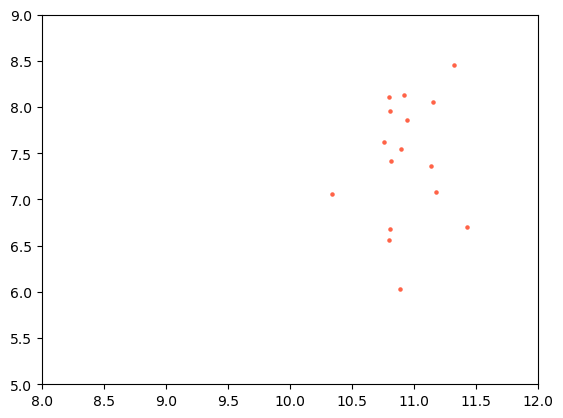

In [3]:
## RECREATE STELLARMASS - BHMASS PLOT 

w = (galaxies_z0.StellarMass > 0) & (galaxies_z0.BlackHoleMass > 0)
m = w & (galaxies_z0.BHmergeCount > 0)
r = w & (galaxies_z0.BHrefillCount > 0) & (galaxies_z0.BHejectFlag == 0)



stellar_mass = np.log10(galaxies_z0.StellarMass[w] * 1e10 / hubble_h)
bh_mass = np.log10(galaxies_z0.BlackHoleMass[w] * 1e10 / hubble_h)

stellar_mass_merge = np.log10(galaxies_z0.StellarMass[m] * 1e10 / hubble_h)
bh_mass_merge = np.log10(galaxies_z0.BlackHoleMass[m] * 1e10 / hubble_h)

stellar_mass_refill = np.log10(galaxies_z0.StellarMass[r] * 1e10 / hubble_h)
bh_mass_refill = np.log10(galaxies_z0.BlackHoleMass[r] * 1e10 / hubble_h)


# plt.scatter(
#     stellar_mass,
#     bh_mass,
#     marker = 'o',
#     color = 'grey',
#     s=1,
#     alpha = 0.2
# )

# plt.scatter(
#     stellar_mass_merge,
#     bh_mass_merge,
#     marker = 'o',
#     color = 'cornflowerblue',
#     s=5
# )

plt.scatter(
    stellar_mass_refill,
    bh_mass_refill,
    marker = 'o',
    color = 'tomato',
    s=5
)
plt.xlim(8.0, 12.0)
plt.ylim(5, 9)

[          1119     1000000000     4000000000     7000000000
  2241000000000  4465000000000  4476000000000  6708000000000
  8925000000933  8931000000000  8936000000000  8937000000000
  8944000000000 13387000000561 13389000000000 13392000000000
 13398000000000]
Amount of BHs ejected for galaxy 1119 : 1
Amount of BHs ejected for galaxy 1000000000 : 1
Amount of BHs ejected for galaxy 4000000000 : 1
Amount of BHs ejected for galaxy 7000000000 : 1
Amount of BHs ejected for galaxy 2241000000000 : 1
Amount of BHs ejected for galaxy 4465000000000 : 1
Amount of BHs ejected for galaxy 4476000000000 : 1
Amount of BHs ejected for galaxy 6708000000000 : 1
Amount of BHs ejected for galaxy 8925000000933 : 1
Amount of BHs ejected for galaxy 8931000000000 : 1
Amount of BHs ejected for galaxy 8936000000000 : 1
Amount of BHs ejected for galaxy 8937000000000 : 1
Amount of BHs ejected for galaxy 8944000000000 : 1
Amount of BHs ejected for galaxy 13387000000561 : 1
Amount of BHs ejected for galaxy 133890000

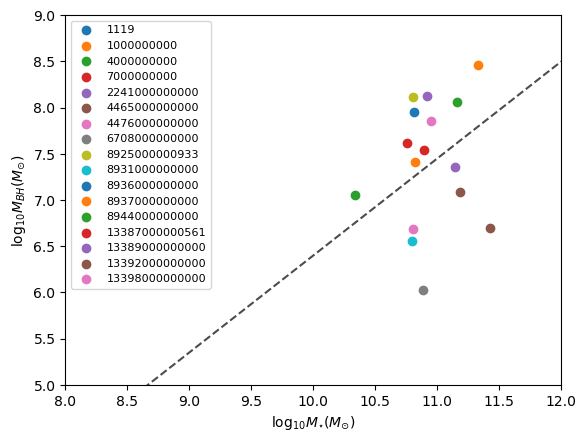

In [4]:

w = (galaxies_z0.StellarMass > 0) & (galaxies_z0.BlackHoleMass > 0)
r = w & (galaxies_z0.BHrefillCount > 0) & (galaxies_z0.BHejectFlag == 0)

gal_ids_refilled = galaxies_z0.GalaxyIndex[r]
print(gal_ids_refilled)

gal_id = 1119


for i in range(len(galaxies_z0)):
        if (galaxies_z0.GalaxyIndex[i] in gal_ids_refilled):
            gal_id = galaxies_z0.GalaxyIndex[i]
            stellar_mass = np.log10(galaxies_z0.StellarMass[i] * 1e10 / hubble_h)
            bh_mass = np.log10(galaxies_z0.BlackHoleMass[i] * 1e10 / hubble_h)
            plt.scatter(stellar_mass, bh_mass, marker='o', label = gal_id)
            print('Amount of BHs ejected for galaxy', gal_id,':', galaxies_z0.BHejectCount[i])
x_hr_r = np.logspace(8, 12, 100)
y_hr_r = 10 ** (7.45) * (x_hr_r / 1.0e11) ** 1.05
plt.plot(np.log10(x_hr_r), np.log10(y_hr_r), color = "black", alpha = 0.7, linestyle = "--")
plt.legend(fontsize=8)
plt.xlabel(r'log$_{10}M_{\star}(M_{\odot})$')
plt.ylabel(r'log$_{10}M_{BH}(M_{\odot})$')
plt.xlim(8.0, 12.0)
plt.ylim(5, 9)
plt.show()


{np.int64(2241000000000): 4.1800000013468, np.int64(13392000000000): 4.0100000101202005, np.int64(1119): 3.0099999936241, np.int64(4000000000): 3.0099999936241, np.int64(13387000000561): 2.5799999992124003, np.int64(8925000000933): 2.209999997432, np.int64(1000000000): 1.90000000174, np.int64(13389000000000): 1.90000000174, np.int64(4465000000000): 1.8200000006204, np.int64(8931000000000): 1.6700000014685004, np.int64(4476000000000): 1.5999999974000003, np.int64(8937000000000): 1.5999999974000003, np.int64(8936000000000): 1.5299999999747, np.int64(7000000000): 1.3599999975456, np.int64(13398000000000): 1.0400000017952, np.int64(8944000000000): 0.4000000005600002, np.int64(6708000000000): 0.34999999952750005}


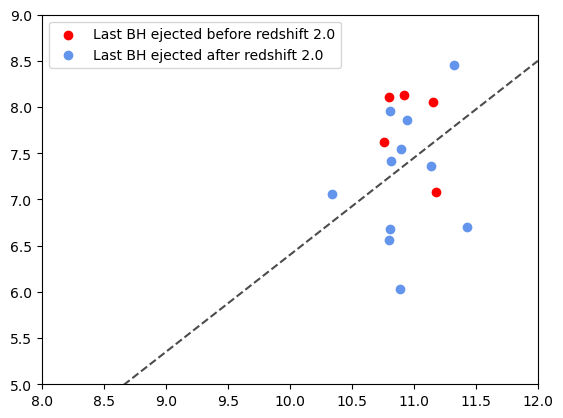

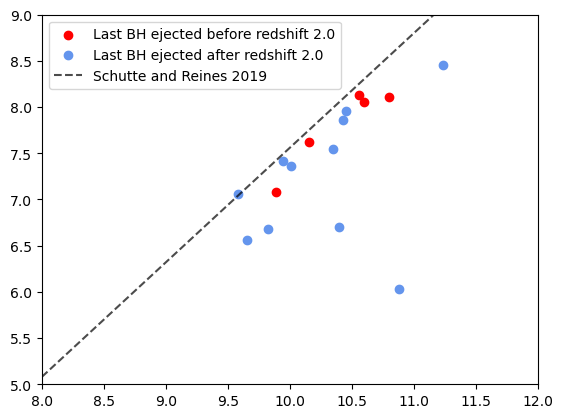

In [5]:
## MAKE PLOT FOR EJECT TIME CUTOFF AND BLACK HOLE - STELLAR MASS PLOT

eject_redshift_b = []
eject_stellarmass_b = []
eject_bulgemass_b = []
eject_bhmass_b = []
eject_redshift_a = []
eject_stellarmass_a = []
eject_bulgemass_a = []
eject_bhmass_a = []
redshift_eject_cutoff = 2.0 # canonical galaxy merger redshift

eject_id_redshift = {}

for snap in range(0, 100):
    galaxies_z0 = data[snap][0]
    metadata = data[snap][2]
    array_length = len(galaxies_z0)

    for i in range(array_length):
        if (galaxies_z0.BHEjectedTime[i] > 0) & (galaxies_z0.GalaxyIndex[i] in gal_ids_refilled):
            redshift = metadata['redshift']
            gal_id = galaxies_z0.GalaxyIndex[i]

            eject_id_redshift[gal_id] = redshift

print(eject_id_redshift)

for i in range(len(galaxies_z0)):
    gal_id = galaxies_z0.GalaxyIndex[i]
    
    if gal_id in gal_ids_refilled:
        redshift = eject_id_redshift[gal_id]

        stellar_mass = np.log10(galaxies_z0.StellarMass[i] * 1e10 / hubble_h)
        bulge_mass = np.log10(galaxies_z0.BulgeMass[i] * 1e10 / hubble_h)
        bh_mass = np.log10(galaxies_z0.BlackHoleMass[i] * 1e10 / hubble_h)

        if redshift >= redshift_eject_cutoff:
            eject_redshift_b.append(redshift)
            eject_stellarmass_b.append(stellar_mass)
            eject_bulgemass_b.append(bulge_mass)
            eject_bhmass_b.append(bh_mass)
        if redshift < redshift_eject_cutoff:
            eject_redshift_a.append(redshift)
            eject_stellarmass_a.append(stellar_mass)
            eject_bulgemass_a.append(bulge_mass)
            eject_bhmass_a.append(bh_mass)


plt.scatter(eject_stellarmass_b, eject_bhmass_b, marker='o', color='red', label = f'Last BH ejected before redshift {redshift_eject_cutoff}')
plt.scatter(eject_stellarmass_a, eject_bhmass_a, marker='o', color='cornflowerblue', label = f'Last BH ejected after redshift {redshift_eject_cutoff}')
plt.plot(np.log10(x_hr_r), np.log10(y_hr_r), color = "black", alpha = 0.7, linestyle = "--")
plt.legend(loc='upper left')
plt.xlim(8, 12)
plt.ylim(5, 9)
plt.show()

plt.scatter(eject_bulgemass_b, eject_bhmass_b, marker='o', color='red', label = f'Last BH ejected before redshift {redshift_eject_cutoff}')
plt.scatter(eject_bulgemass_a, eject_bhmass_a, marker='o', color='cornflowerblue', label = f'Last BH ejected after redshift {redshift_eject_cutoff}')
x_hr_9 = np.logspace(8, 12, 100)
y_hr_9 = 10 ** (8.8) * (x_hr_9 / 1.0e11) ** 1.24
plt.plot(np.log10(x_hr_9), np.log10(y_hr_9), color = "black", alpha = 0.7, linestyle = "--", label="Schutte and Reines 2019")
plt.legend(loc='upper left')
plt.xlim(8, 12)
plt.ylim(5, 9)
plt.show()

Loaded 100 redshift values from /Users/pater32/Documents/GitHub/sage/mergertrees/illustristng/illustristng.a_list
Reading galaxy data from /Users/pater32/Documents/GitHub/sage/GWRecoil/output/results/illustristng/tng50_4/run1/model_z0.000
Input files contain: 15618 trees, 22283 galaxies.
Reading 22283 galaxies from file: /Users/pater32/Documents/GitHub/sage/GWRecoil/output/results/illustristng/tng50_4/run1/model_z0.000_0
{np.int64(4000000000): 2.7299999964565003, np.int64(1119): 2.000000003, np.int64(13392000000000): 2.000000003, np.int64(8925000000933): 1.8200000006204, np.int64(1000000000): 1.7399999973695999, np.int64(4476000000000): 1.5299999999747, np.int64(8937000000000): 1.1500000003224997, np.int64(13389000000000): 1.0700000018837001, np.int64(13387000000561): 0.7600000005631999, np.int64(13398000000000): 0.7000000003400002, np.int64(2241000000000): 0.6399999988192, np.int64(8936000000000): 0.3300000004389001, np.int64(7000000000): 0.2599999994455999, np.int64(8944000000000): 0

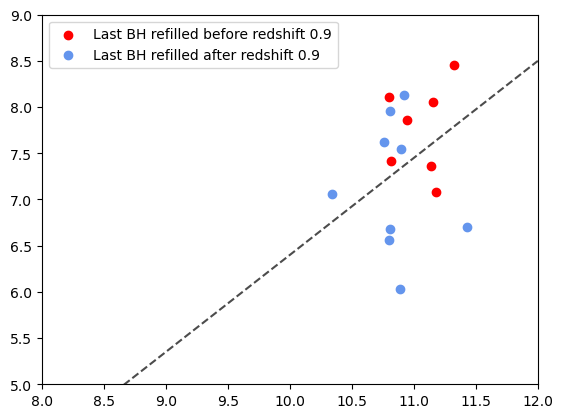

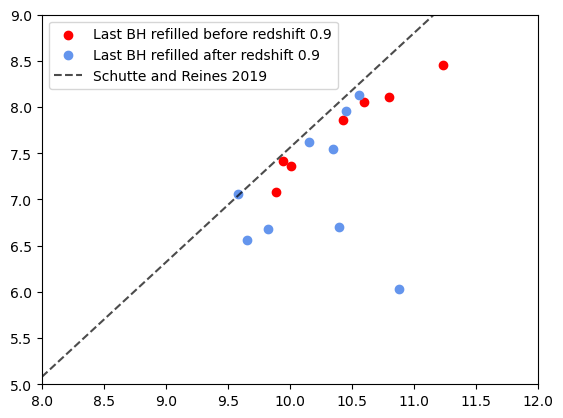

In [6]:
## MAKE PLOT FOR REFILL TIME CUTOFF AND BLACK HOLE - STELLAR MASS PLOT

refill_redshift_b = []
refill_stellarmass_b = []
refill_bulgemass_b = []
refill_bhmass_b = []
refill_redshift_a = []
refill_stellarmass_a = []
refill_bulgemass_a = []
refill_bhmass_a = []
redshift_refill_cutoff = .9

refill_id_redshift = {}

galaxies_z0_z0, volume, metadata = load_snapshot(param_file, 99)

for snap in range(0, 100):
    galaxies_z0 = data[snap][0]
    metadata = data[snap][2]
    array_length = len(galaxies_z0)

    for i in range(array_length):
        if (galaxies_z0.BHRefilledTime[i] > 0) & (galaxies_z0.GalaxyIndex[i] in gal_ids_refilled):
            redshift = metadata['redshift']
            gal_id = galaxies_z0.GalaxyIndex[i]

            refill_id_redshift[gal_id] = redshift

print(refill_id_redshift)

for i in range(len(galaxies_z0_z0)):
    gal_id = galaxies_z0_z0.GalaxyIndex[i]
    
    if gal_id in gal_ids_refilled:
        redshift = refill_id_redshift[gal_id]

        stellar_mass = np.log10(galaxies_z0_z0.StellarMass[i] * 1e10 / hubble_h)
        bulge_mass = np.log10(galaxies_z0_z0.BulgeMass[i] * 1e10 / hubble_h)
        bh_mass = np.log10(galaxies_z0_z0.BlackHoleMass[i] * 1e10 / hubble_h)

        if redshift >= redshift_refill_cutoff:
            refill_redshift_b.append(redshift)
            refill_stellarmass_b.append(stellar_mass)
            refill_bulgemass_b.append(bulge_mass)
            refill_bhmass_b.append(bh_mass)
        if redshift < redshift_refill_cutoff:
            refill_redshift_a.append(redshift)
            refill_stellarmass_a.append(stellar_mass)
            refill_bulgemass_a.append(bulge_mass)
            refill_bhmass_a.append(bh_mass)


plt.scatter(refill_stellarmass_b, refill_bhmass_b, marker='o', color='red', label = f'Last BH refilled before redshift {redshift_refill_cutoff}')
plt.scatter(refill_stellarmass_a, refill_bhmass_a, marker='o', color='cornflowerblue', label = f'Last BH refilled after redshift {redshift_refill_cutoff}')
plt.plot(np.log10(x_hr_r), np.log10(y_hr_r), color = "black", alpha = 0.7, linestyle = "--")
plt.legend(loc='upper left')
plt.xlim(8, 12)
plt.ylim(5, 9)
plt.show()

plt.scatter(refill_bulgemass_b, refill_bhmass_b, marker='o', color='red', label = f'Last BH refilled before redshift {redshift_refill_cutoff}')
plt.scatter(refill_bulgemass_a, refill_bhmass_a, marker='o', color='cornflowerblue', label = f'Last BH refilled after redshift {redshift_refill_cutoff}')
x_hr_9 = np.logspace(8, 12, 100)
y_hr_9 = 10 ** (8.8) * (x_hr_9 / 1.0e11) ** 1.24
plt.plot(np.log10(x_hr_9), np.log10(y_hr_9), color = "black", alpha = 0.7, linestyle = "--", label="Schutte and Reines 2019")
plt.legend(loc='upper left')
plt.xlim(8, 12)
plt.ylim(5, 9)
plt.show()

Loaded 100 redshift values from /Users/pater32/Documents/GitHub/sage/mergertrees/illustristng/illustristng.a_list
Reading galaxy data from /Users/pater32/Documents/GitHub/sage/GWRecoil/output/results/illustristng/tng50_4/run1/model_z0.000
Input files contain: 15618 trees, 22283 galaxies.
Reading 22283 galaxies from file: /Users/pater32/Documents/GitHub/sage/GWRecoil/output/results/illustristng/tng50_4/run1/model_z0.000_0


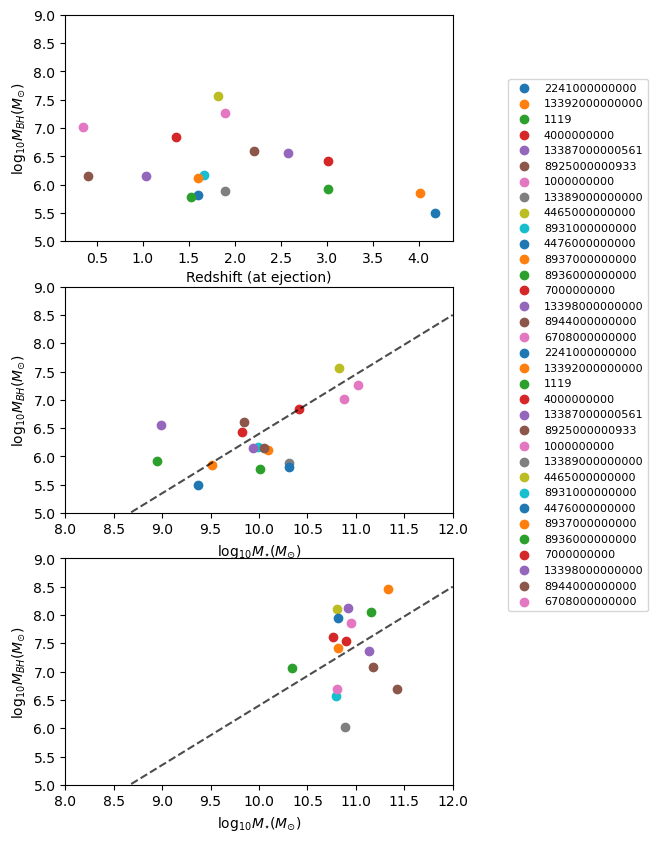

In [7]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(5, 10))

labels_used = []
for snap in range(0, 100):
    galaxies_z0 = data[snap][0]
    metadata = data[snap][2]
    array_length = len(galaxies_z0)

    for i in range(array_length):
        if (galaxies_z0.BHEjectedTime[i] > 0) & (galaxies_z0.GalaxyIndex[i] in gal_ids_refilled):
            gal_id = galaxies_z0.GalaxyIndex[i] 
            label = gal_id if gal_id not in labels_used else None
            labels_used.append(gal_id)


            redshift = metadata['redshift']
            hubble_h = metadata['hubble_h']
            # print('BH for galaxy', gal_id, 'was ejected at redshift:', redshift)
            stellar_mass_ejected = np.log10(galaxies_z0.StellarMass[i] * 1e10 / hubble_h)
            bh_mass_ejected = np.log10(galaxies_z0.MassofLastEjectedBH[i] * 1e10 / hubble_h)
            eject_time = galaxies_z0.BHEjectedTime[i]

            ax1.scatter(redshift, bh_mass_ejected, marker='o', label=label)
            ax2.scatter(stellar_mass_ejected, bh_mass_ejected, marker='o', label=label)

        # if (galaxies_z0.BHRefilledTime[i] > 0) & (galaxies_z0.GalaxyIndex[i] == gal_id):
        #     redshift = metadata['redshift']
        #     hubble_h = metadata['hubble_h']
        #     print('BH for galaxy', gal_id, 'was refilled at redshift:', redshift)

galaxies_z0_current, volume, metadata = load_snapshot(param_file, 99)
for i in range(len(galaxies_z0_current)):
    if galaxies_z0_current.GalaxyIndex[i] in gal_ids_refilled:
        gal_id = galaxies_z0_current.GalaxyIndex[i] 
        label = gal_id if gal_id not in labels_used else None
        labels_used.append(gal_id)
        
        stellar_mass_current = np.log10(galaxies_z0_current.StellarMass[i] * 1e10 / hubble_h)
        bh_mass_current = np.log10(galaxies_z0_current.BlackHoleMass[i] * 1e10 / hubble_h)

        ax3.scatter(stellar_mass_current, bh_mass_current, marker='o', label=label)

ax1.set_xlabel('Redshift (at ejection)')
ax1.set_ylabel(r'log$_{10}M_{BH}(M_{\odot})$')
ax1.set_ylim(5, 9)

ax2.plot(np.log10(x_hr_r), np.log10(y_hr_r), color = "black", alpha = 0.7, linestyle = "--")
ax2.set_xlim(8, 12)
ax2.set_ylim(5, 9)
ax2.set_xlabel(r'log$_{10}M_{\star}(M_{\odot})$')
ax2.set_ylabel(r'log$_{10}M_{BH}(M_{\odot})$')

ax3.plot(np.log10(x_hr_r), np.log10(y_hr_r), color = "black", alpha = 0.7, linestyle = "--")
ax3.set_xlim(8, 12)
ax3.set_ylim(5, 9)
ax3.set_xlabel(r'log$_{10}M_{\star}(M_{\odot})$')
ax3.set_ylabel(r'log$_{10}M_{BH}(M_{\odot})$')

fig.legend(fontsize = 8, loc='center left', bbox_to_anchor = (1, .55))
plt.show()



In [8]:
## CHECK THAT MERGE AND REFILL OVERLAP IS THE SAME LENGTH AS REFILL

refill_count = []

for i in range(len(stellar_mass_refill)):
    for j in range(len(stellar_mass_merge)):
        if stellar_mass_refill[i] == stellar_mass_merge[j]:
            refill_count.append(stellar_mass_merge)

print(len(np.array(refill_count)))
print(len(stellar_mass_refill))

galaxies_z0 = load_snapshot(param_file, 0)
print(galaxies_z0)
    

17
17
Loaded 100 redshift values from /Users/pater32/Documents/GitHub/sage/mergertrees/illustristng/illustristng.a_list
Reading galaxy data from /Users/pater32/Documents/GitHub/sage/GWRecoil/output/results/illustristng/tng50_4/run1/model_z20.050
Input files contain: 15618 trees, 0 galaxies.
Reading 0 galaxies from file: /Users/pater32/Documents/GitHub/sage/GWRecoil/output/results/illustristng/tng50_4/run1/model_z20.050_0
(rec.array([],
          dtype={'names': ['SnapNum', 'Type', 'GalaxyIndex', 'CentralGalaxyIndex', 'SAGEHaloIndex', 'SAGETreeIndex', 'SimulationHaloIndex', 'mergeType', 'mergeIntoID', 'mergeIntoSnapNum', 'dT', 'Pos', 'Vel', 'Spin', 'Len', 'Mvir', 'CentralMvir', 'Rvir', 'Vvir', 'Vmax', 'VelDisp', 'ColdGas', 'StellarMass', 'BulgeMass', 'HotGas', 'EjectedMass', 'BlackHoleMass', 'IntraClusterStars', 'NSC', 'MetalsColdGas', 'MetalsStellarMass', 'MetalsBulgeMass', 'MetalsHotGas', 'MetalsEjectedMass', 'MetalsIntraClusterStars', 'SfrDisk', 'SfrBulge', 'SfrDiskZ', 'SfrBulgeZ', '

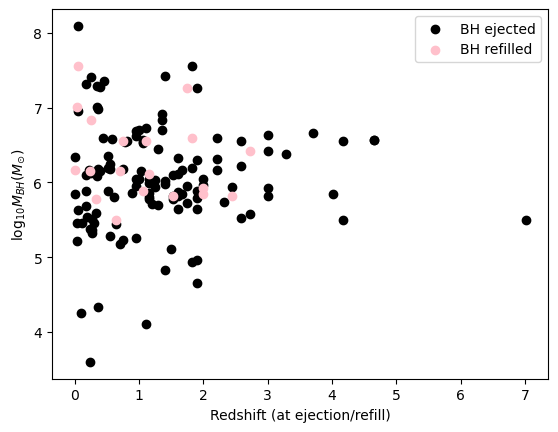

In [9]:
## ANALYZE galaxies_z0 WITH REFILLED BHs
    # data = snap : galaxies_z0, volume, metadata
    # ie: data[2][0] = snapshot 2, galaxies_z0

# w = data[10][0].BHEjectedTime > 0
# print(data[10][0].BHEjectedTime[w])


eject_times = []
refill_times = []
stellar_masses_ejected = []
stellar_masses_refilled = []
bh_masses_ejected = []
bh_masses_refilled = []
merge_types = []
for snap in range(1, 100):
    galaxies_z0 = data[snap][0]
    metadata = data[snap][2]
    array_length = len(galaxies_z0)

    if array_length > 0:
        
        for i in range(array_length):
            if galaxies_z0.BHEjectedTime[i] > 0:
                eject_time = galaxies_z0.BHEjectedTime[i]
                redshift = metadata['redshift']
                tot_ejections = galaxies_z0.BHejectCount[i]
                # print(eject_time, redshift)
                # snap_num = snap - 1 # gal information stored in 
                # print("A BH was ejected for this snapshot:", snap_num, "At time:", eject_time)

                stellar_mass_ejected = np.log10(galaxies_z0.StellarMass[i] * 1e10 / hubble_h)
                bh_mass_ejected = np.log10(galaxies_z0.MassofLastEjectedBH[i] * 1e10 / hubble_h)

                stellar_masses_ejected.append(stellar_mass_ejected)
                bh_masses_ejected.append(bh_mass_ejected)
                eject_times.append(redshift)

            if galaxies_z0.BHRefilledTime[i] > 0:
                refill_time = galaxies_z0.BHRefilledTime[i]
                redshift = metadata['redshift']
                tot_refills = galaxies_z0.BHrefillCount[i]

                stellar_mass_refilled = np.log10(galaxies_z0.StellarMass[i] * 1e10 / hubble_h)
                bh_mass_refilled = np.log10(galaxies_z0.MassofLastEjectedBH[i] * 1e10 / hubble_h)

                stellar_masses_refilled.append(stellar_mass_refilled)
                bh_masses_refilled.append(bh_mass_refilled)
                refill_times.append(redshift)


                



plt.scatter(eject_times, bh_masses_ejected, marker='o', color='black', label='BH ejected')
plt.scatter(refill_times, bh_masses_refilled, marker='o', color='pink', label='BH refilled')
plt.xlabel('Redshift (at ejection/refill)')
plt.ylabel(r'log$_{10}M_{BH}(M_{\odot})$')
plt.legend()
plt.show()



In [10]:
## MAKE HISTOGRAMS FOR galaxies_z0 

# GALAXY SM HISTOGRAM (WHEN WERE THESE BLACK HOLES EJECTED)
min_sm = 7.0
max_sm = 12.0
interval = 0.5
n_bins = int((max_sm-min_sm)/interval)
hist, edges_sm = np.histogram(stellar_mass, range = (min_sm, max_sm), bins = n_bins)
plt.hist(stellar_masses, bins=edges_sm, density = True, color = 'cornflowerblue', edgecolor='white')
plt.xlabel('Stellar Mass')
plt.ylabel('Fraction of BHs ejected')
plt.title('Stellar Mass of galaxies_z0 at BH Ejection')
plt.ylim(0, 1)
plt.show()

# BLACK HOLE MASS AT EJECTION 
min_bh = 3.0
max_bh = 8.0
interval = 0.5
n_bins = int((max_bh-min_bh)/interval)
hist, edges_bh = np.histogram(bh_mass, range = (min_bh, max_bh), bins = n_bins)
plt.hist(bh_masses, bins=edges_bh, density = True, color = 'cornflowerblue', edgecolor='white')
plt.xlabel('BH Mass')
plt.ylabel('Fraction of BHs ejected')
plt.title('Black Hole Mass at Ejection')
plt.ylim(0, 1)
plt.show()

min_z = 0
max_z = 21.0
interval = 1
n_bins = int((max_z-min_z)/interval)
hist, edges_z = np.histogram(eject_times, range = (min_z, max_z), bins = n_bins)
plt.hist(eject_times, bins=edges_z, density = True, color = 'cornflowerblue', edgecolor='white')
plt.xlabel('z')
plt.ylabel('Fraction of BHs ejected')
plt.title('Redshift at BH Ejection')
plt.ylim(0, 1)
plt.show()

NameError: name 'stellar_masses' is not defined

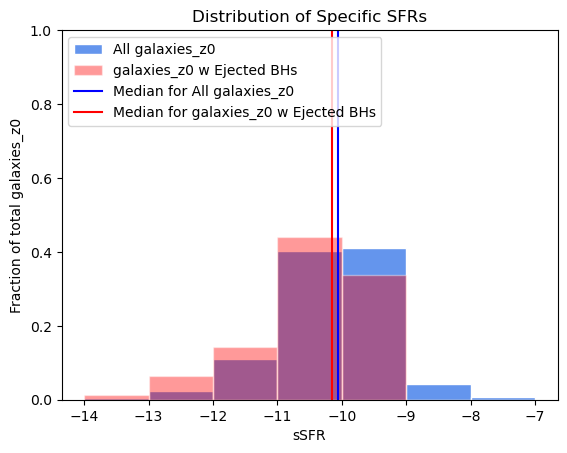

5949
-10.052984
78
-10.146369
12
-10.027212


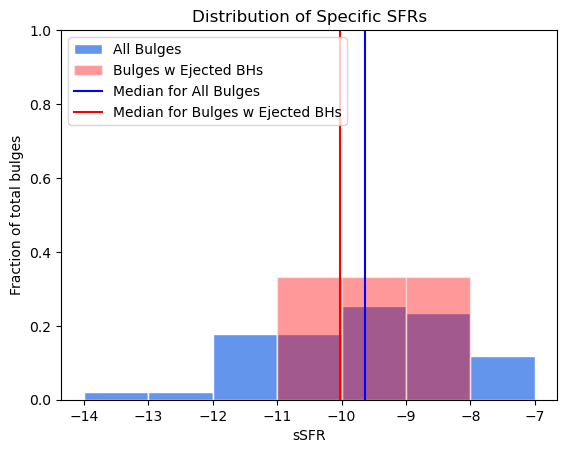

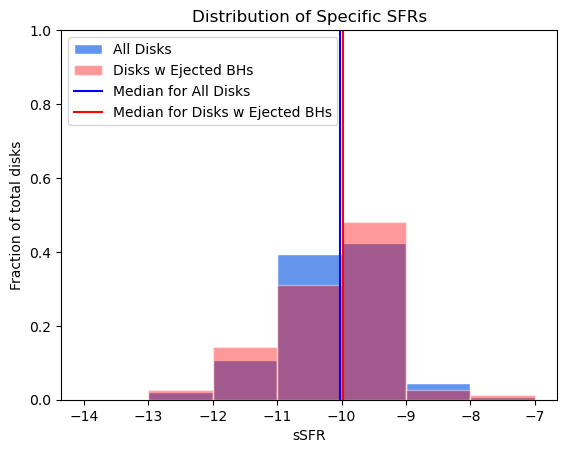

In [11]:
## STELLAR POPULATIONS OF ALL galaxies_z0 VS galaxies_z0 W/ REFILLED BLACK HOLES

all_ssfrs = []
all_bulge_ssfrs = []
all_disk_ssfrs = []
all_bhs = []

ejected_ssfrs = []
ejected_bulge_ssfrs = []
ejected_disk_ssfrs = []
ejected_bhs = []

refilled_ssfrs = []
nobh_ssfrs = []



galaxies_z0 = data[99][0]
metadata = data[99][2]
hubble_h = metadata['hubble_h']
array_length = len(galaxies_z0)

for i in range(array_length):
    sfr = galaxies_z0.SfrDisk[i] + galaxies_z0.SfrBulge[i]
    bulge_sfr = galaxies_z0.SfrBulge[i]
    disk_sfr = galaxies_z0.SfrDisk[i]

    if (sfr > 0):
        stellar_mass = galaxies_z0.StellarMass[i] * 1e10 / hubble_h
        sSFR = np.log10(sfr/stellar_mass)
        all_ssfrs.append(sSFR)

        if galaxies_z0.BHejectCount[i] > 0:
            ejected_ssfrs.append(sSFR)
            ejected_bhs.append(bh_mass)
        
        if galaxies_z0.BHrefillCount[i] > 0:
            refilled_ssfrs.append(sSFR)

    if (bulge_sfr > 0):
        bulge_mass = galaxies_z0.BulgeMass[i] * 1e10 / hubble_h
        bulge_sSFR = np.log10(bulge_sfr/bulge_mass)
        all_bulge_ssfrs.append(bulge_sSFR)

        if galaxies_z0.BHejectCount[i] > 0:
            ejected_bulge_ssfrs.append(bulge_sSFR)
    
    if (disk_sfr > 0):
        disk_mass = (galaxies_z0.StellarMass[i] - galaxies_z0.BulgeMass[i]) * 1e10 / hubble_h
        disk_sSFR = np.log10(disk_sfr/disk_mass)
        all_disk_ssfrs.append(disk_sSFR)

        if galaxies_z0.BHejectCount[i] > 0:
            ejected_disk_ssfrs.append(disk_sSFR)

    

min_z = -14
max_z = -7
interval = 1
n_bins = int((max_z-min_z)/interval)
hist, edges = np.histogram(all_ssfrs, range = (min_z, max_z), bins = n_bins)
plt.hist(all_ssfrs, bins=edges, density = True, color = 'cornflowerblue', edgecolor='white', label='All galaxies_z0')
plt.hist(ejected_ssfrs, bins=edges, density = True, color = 'red', alpha=.4, edgecolor='white', label='galaxies_z0 w Ejected BHs')
#plt.hist(refilled_ssfrs, bins=edges, density = True, color = 'red', alpha=.4, edgecolor='white', label='galaxies_z0 w Refilled BHs')
plt.axvline(np.median(all_ssfrs), color = 'blue', label = 'Median for All galaxies_z0')
plt.axvline(np.median(ejected_ssfrs), color = 'red', label = 'Median for galaxies_z0 w Ejected BHs')
#plt.axvline(np.median(refilled_ssfrs), color = 'red', label = 'Median for galaxies_z0 w Refilled BHs')
plt.xlabel('sSFR')
plt.ylabel('Fraction of total galaxies_z0')
plt.title('Distribution of Specific SFRs')
plt.legend(loc='upper left')
plt.ylim(0, 1)
plt.show()


print(len(all_ssfrs))
print(np.median(all_ssfrs))
print(len(ejected_ssfrs))
print(np.median(ejected_ssfrs))
print(len(refilled_ssfrs))
print(np.median(refilled_ssfrs))

plt.hist(all_bulge_ssfrs, bins=edges, density = True, color = 'cornflowerblue', edgecolor='white', label='All Bulges')
plt.hist(ejected_bulge_ssfrs, bins=edges, density = True, color = 'red', alpha=.4, edgecolor='white', label='Bulges w Ejected BHs')
plt.axvline(np.median(all_bulge_ssfrs), color = 'blue', label = 'Median for All Bulges')
plt.axvline(np.median(ejected_bulge_ssfrs), color = 'red', label = 'Median for Bulges w Ejected BHs')
plt.xlabel('sSFR')
plt.ylabel('Fraction of total bulges')
plt.title('Distribution of Specific SFRs')
plt.legend(loc='upper left')
plt.ylim(0, 1)
plt.show()

plt.hist(all_disk_ssfrs, bins=edges, density = True, color = 'cornflowerblue', edgecolor='white', label='All Disks')
plt.hist(ejected_disk_ssfrs, bins=edges, density = True, color = 'red', alpha=.4, edgecolor='white', label='Disks w Ejected BHs')
plt.axvline(np.median(all_disk_ssfrs), color = 'blue', label = 'Median for All Disks')
plt.axvline(np.median(ejected_disk_ssfrs), color = 'red', label = 'Median for Disks w Ejected BHs')
plt.xlabel('sSFR')
plt.ylabel('Fraction of total disks')
plt.title('Distribution of Specific SFRs')
plt.legend(loc='upper left')
plt.ylim(0, 1)
plt.show()

# plt.scatter(all_bhs, all_ssfrs, color = 'black', marker='o', alpha=.4, s=3, label='All galaxies_z0')
# plt.scatter(ejected_bhs, ejected_ssfrs, color = 'red', marker='o', s=3, label='galaxies_z0 w Ejected BHs')
# plt.axhline(-11, linestyle='dashed', color='red')
# plt.xlabel('Black Hole Mass')
# plt.ylabel('sSFR')
# plt.legend(loc='upper left')

## MAKE PLOT FOR galaxies_z0 WITH EJECTED BLACK HOLES AND THEIR SFR BY REDSHIFT AND AXVLINE WHERE EJECTION OCCURRED 



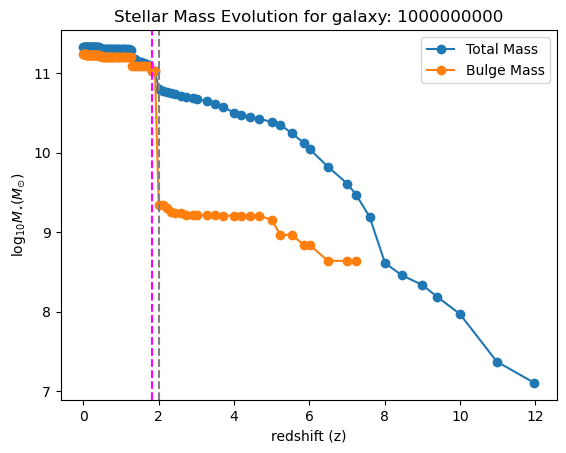

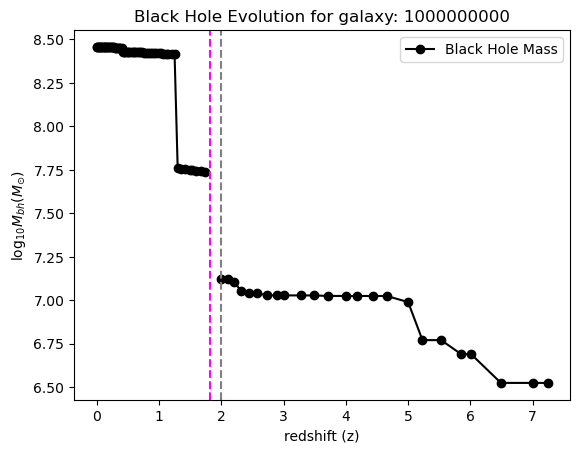

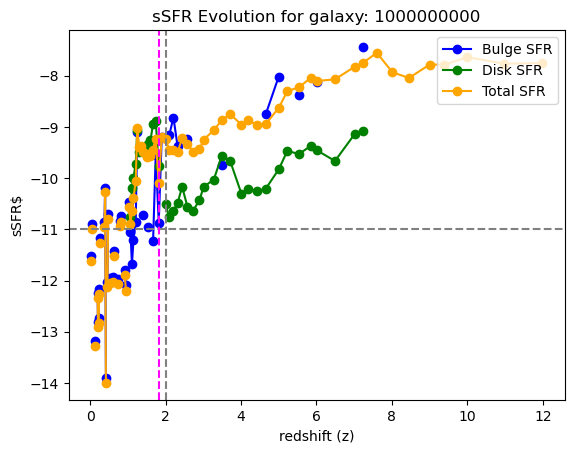

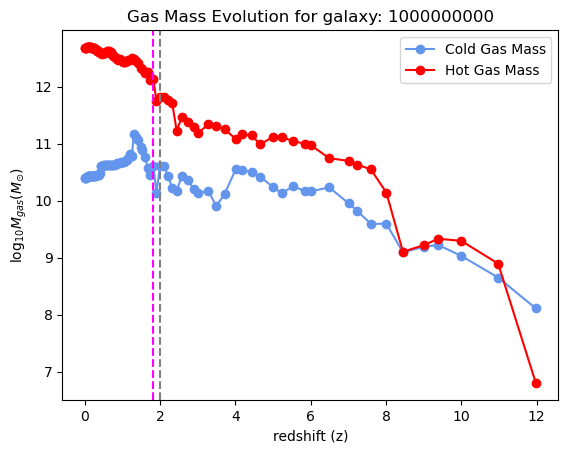

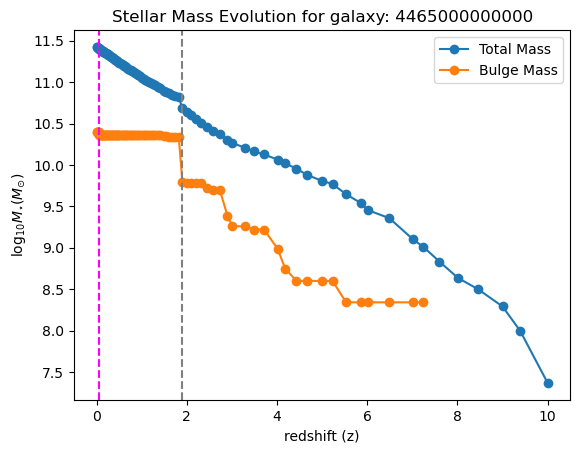

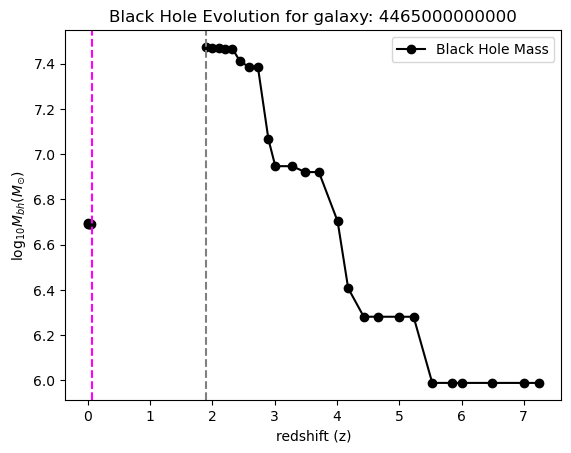

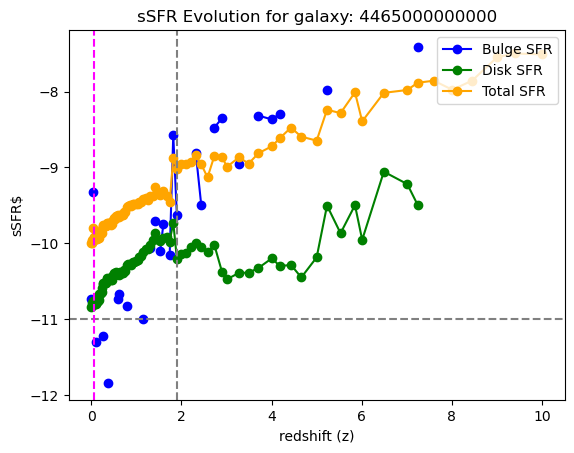

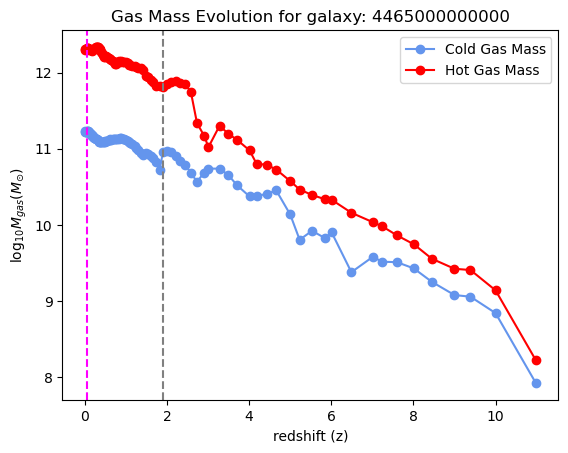

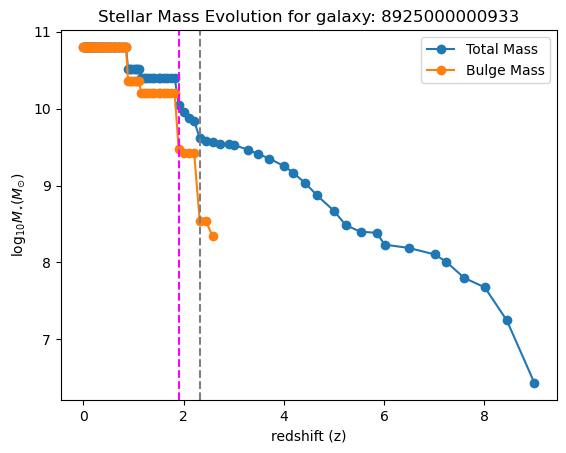

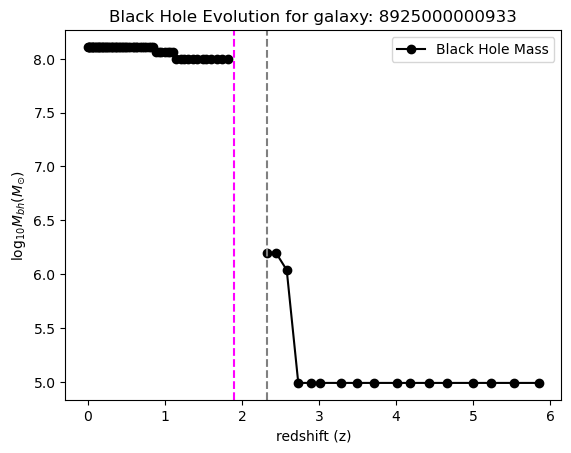

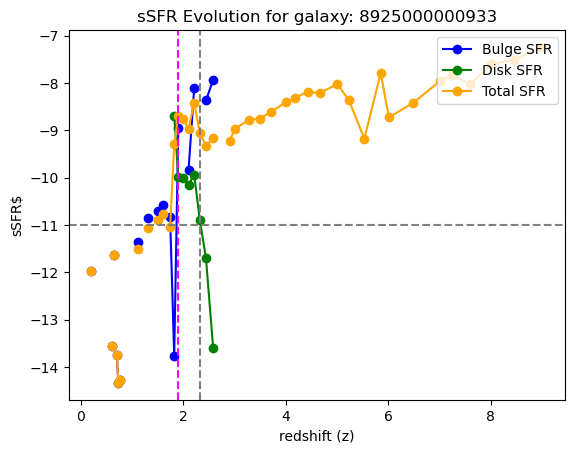

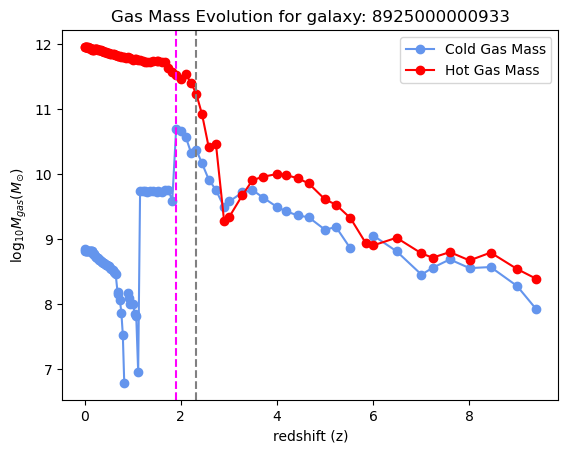

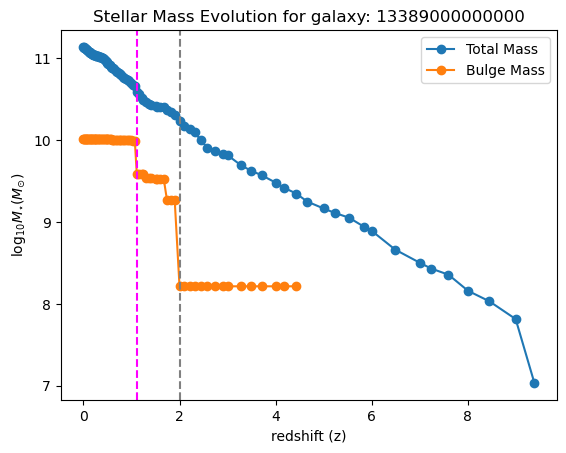

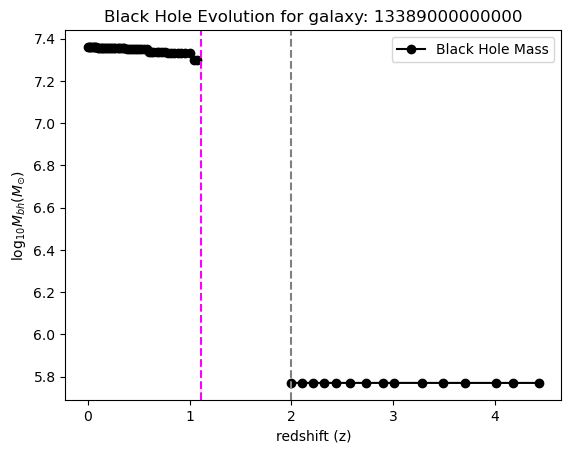

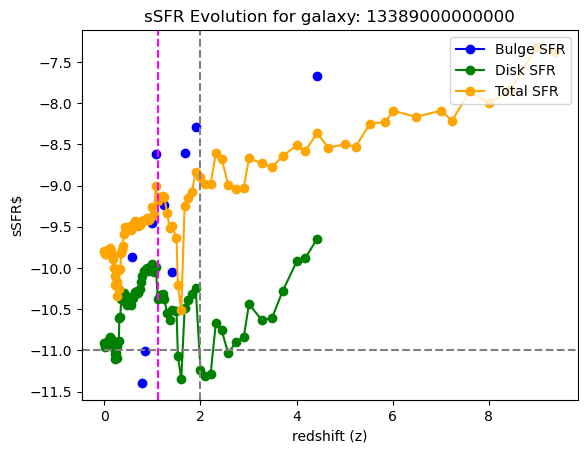

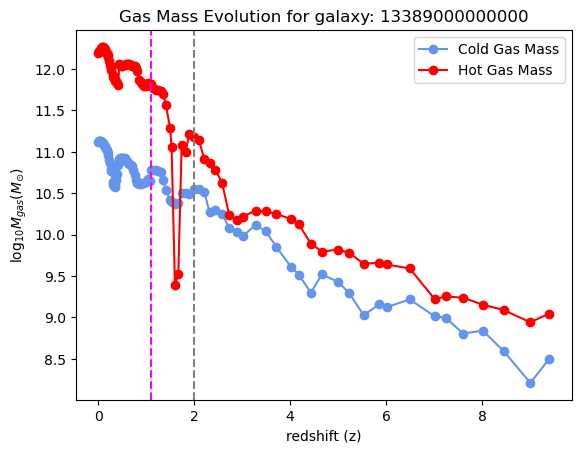

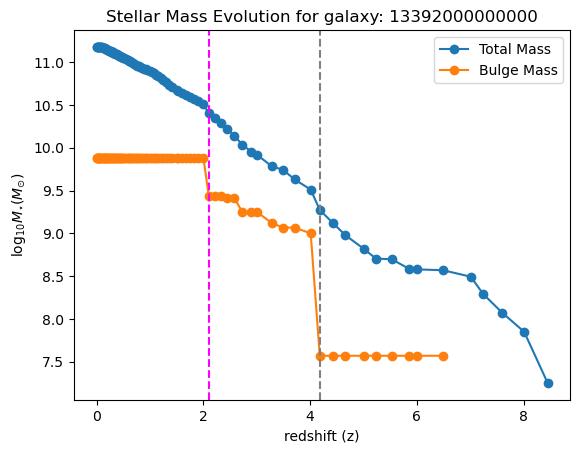

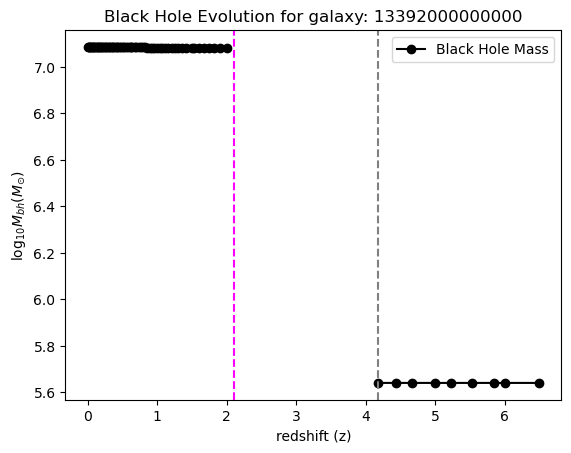

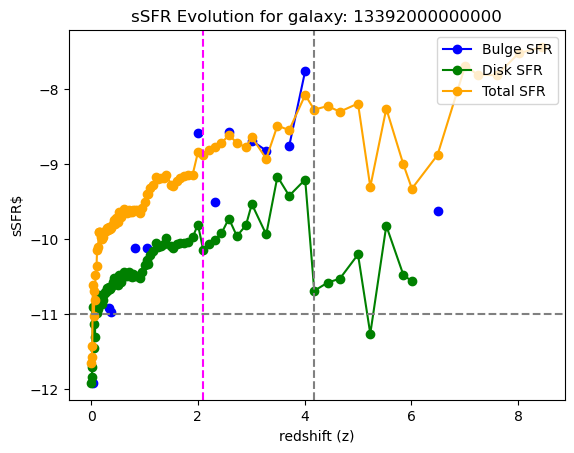

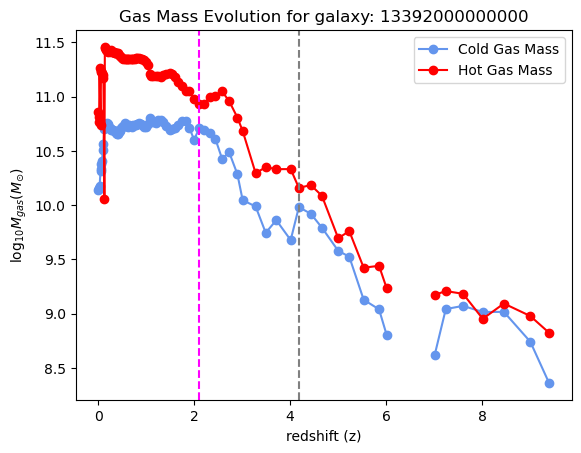

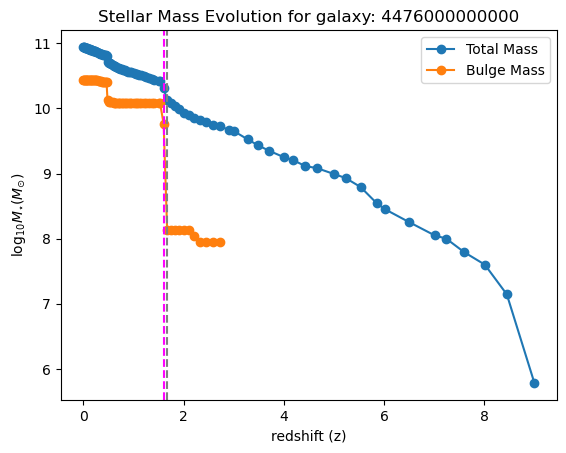

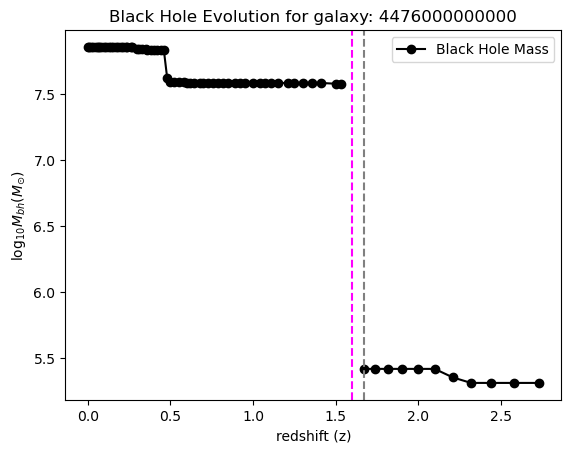

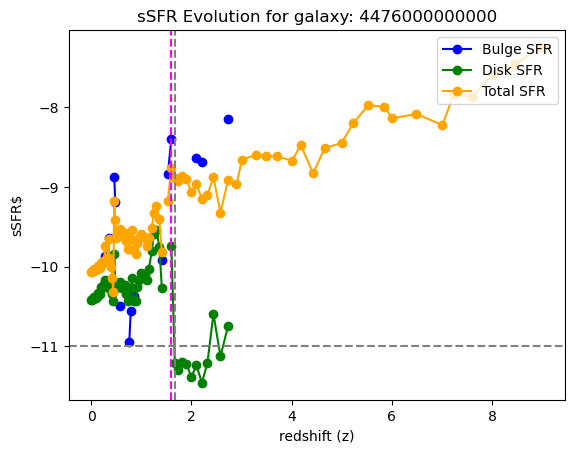

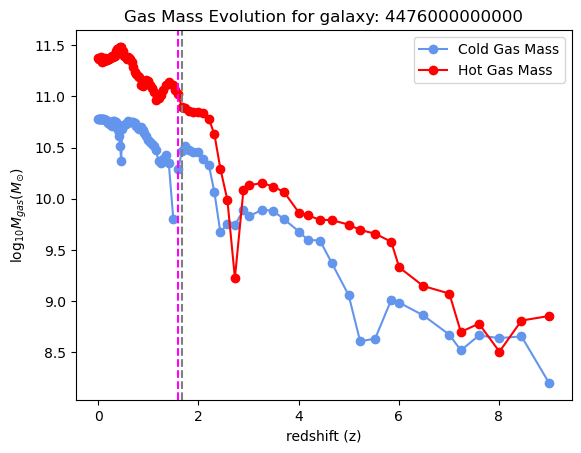

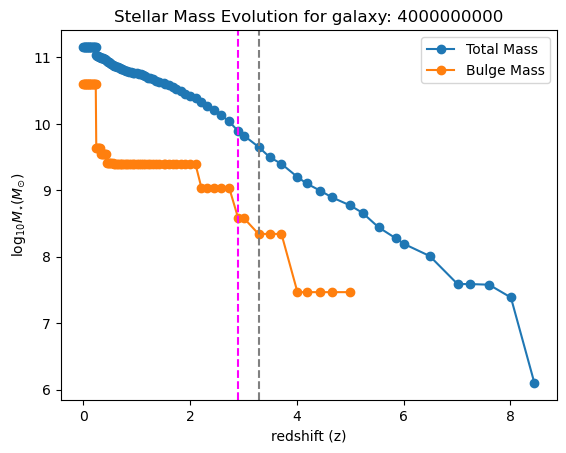

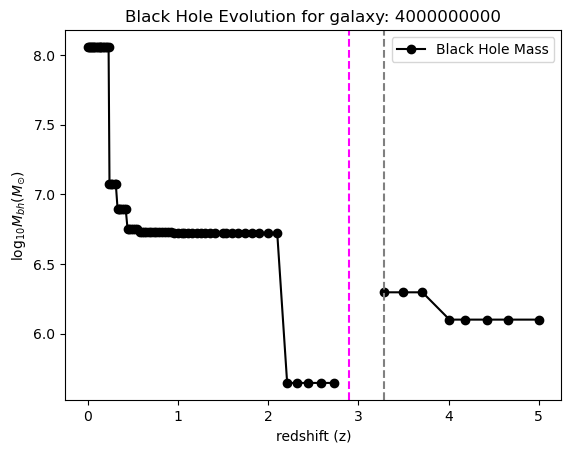

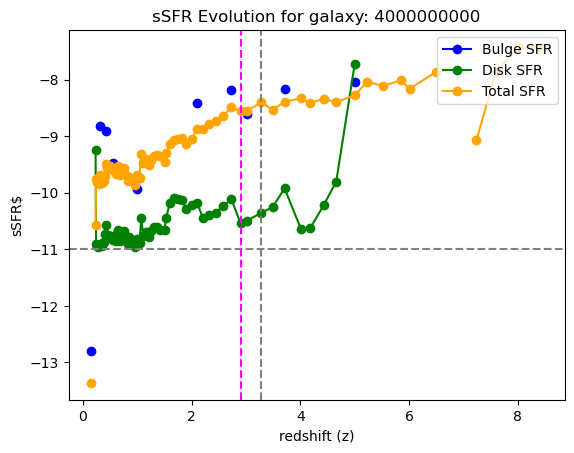

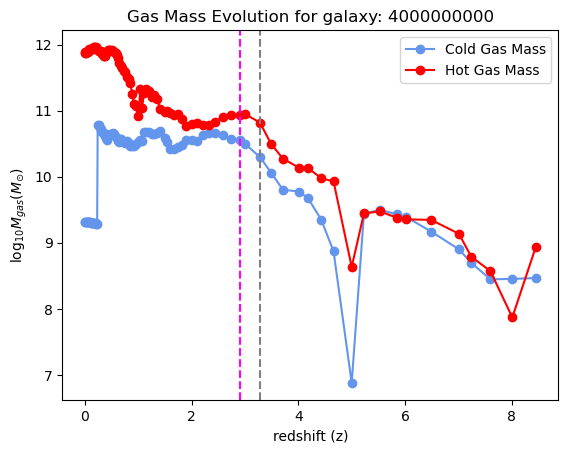

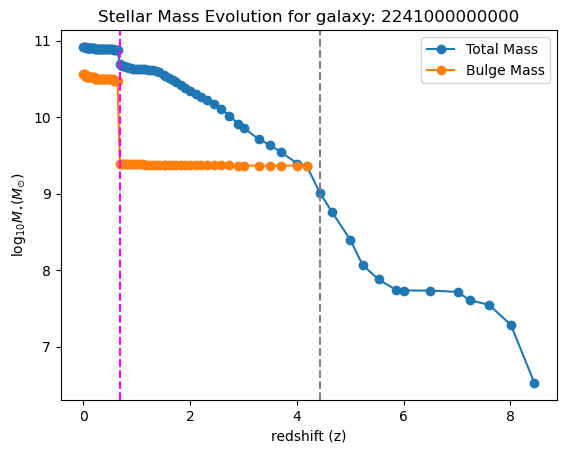

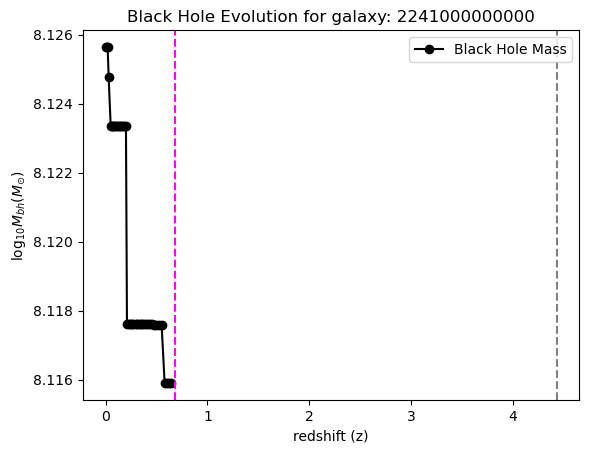

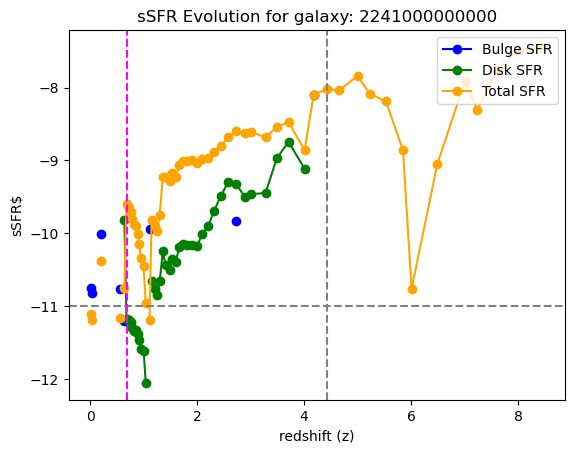

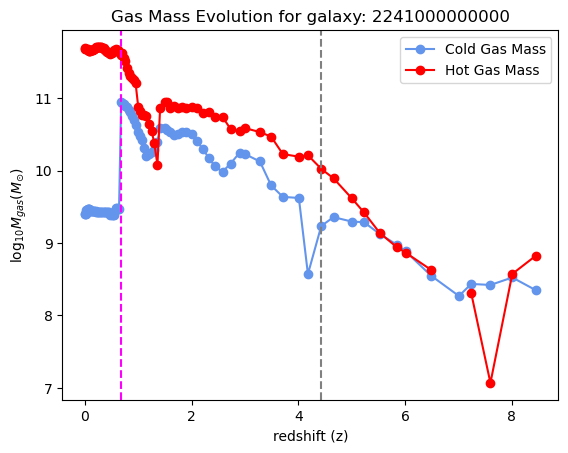

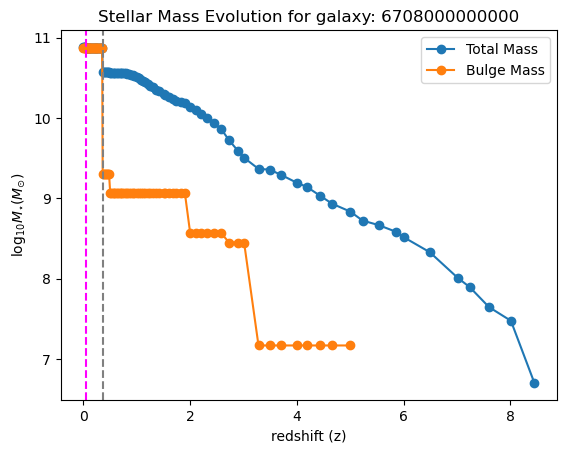

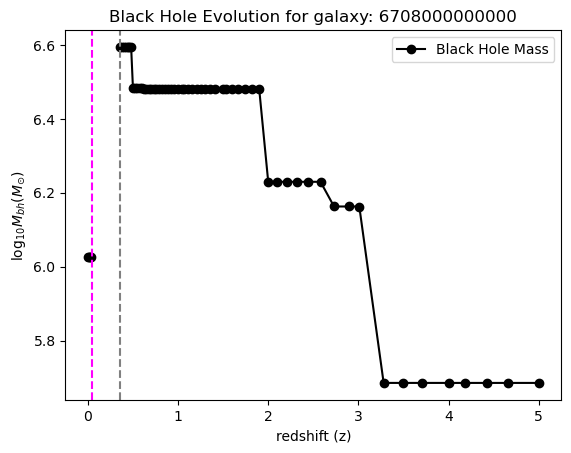

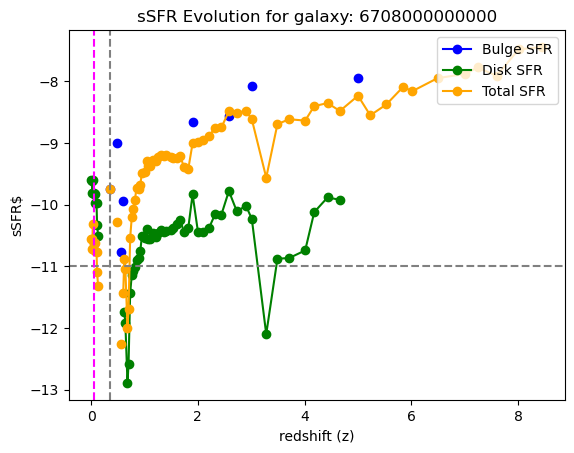

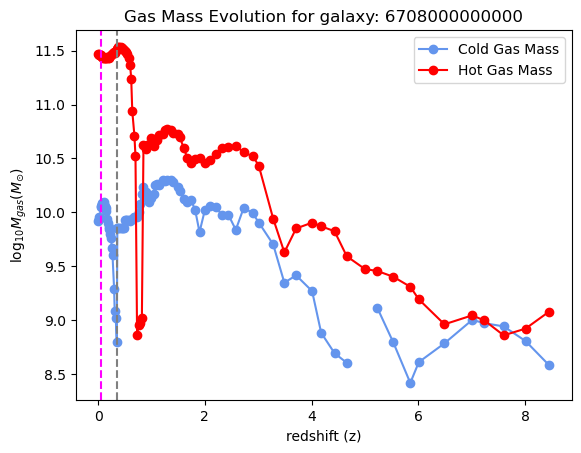

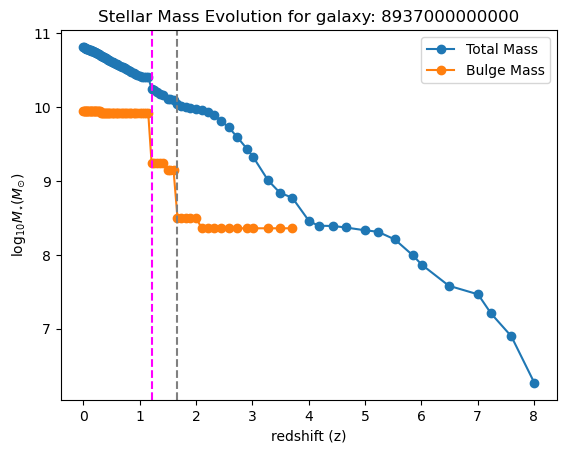

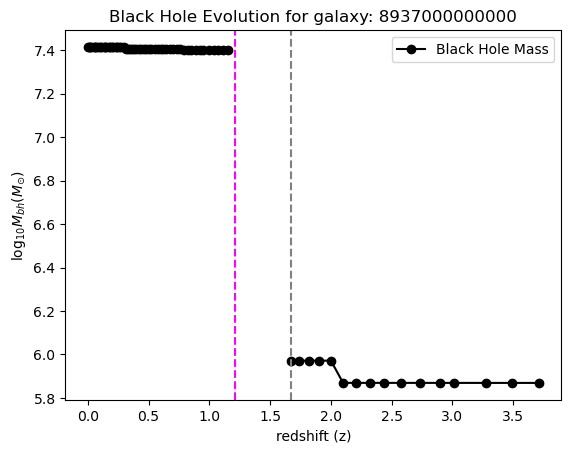

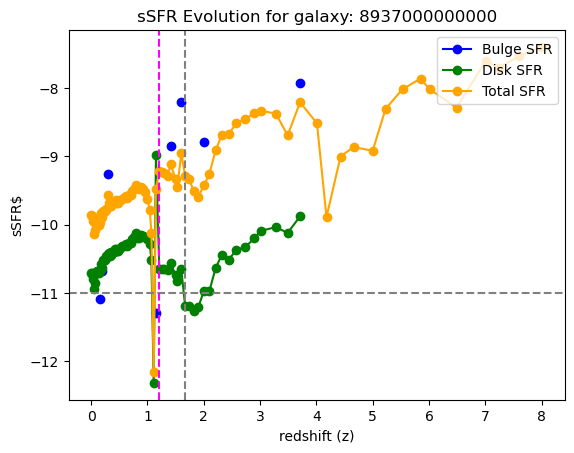

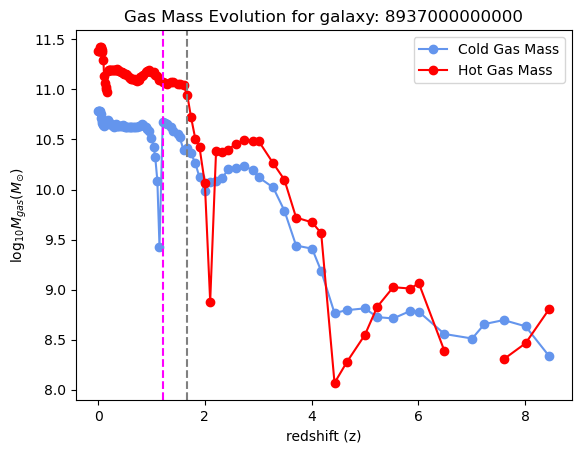

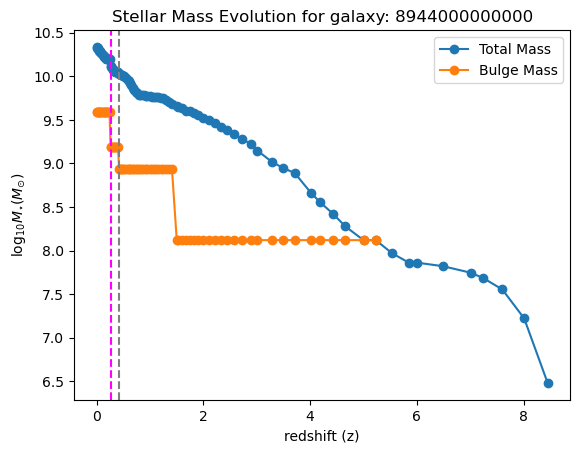

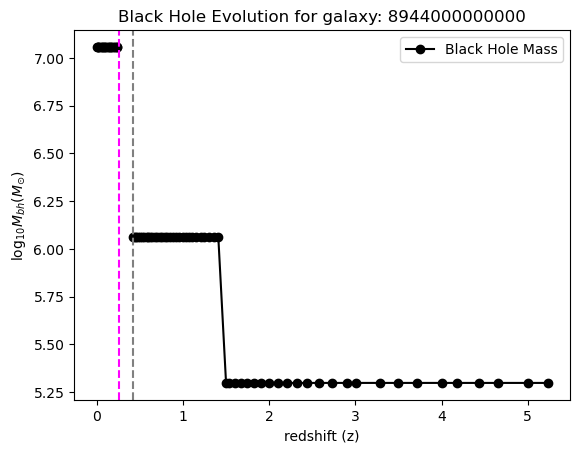

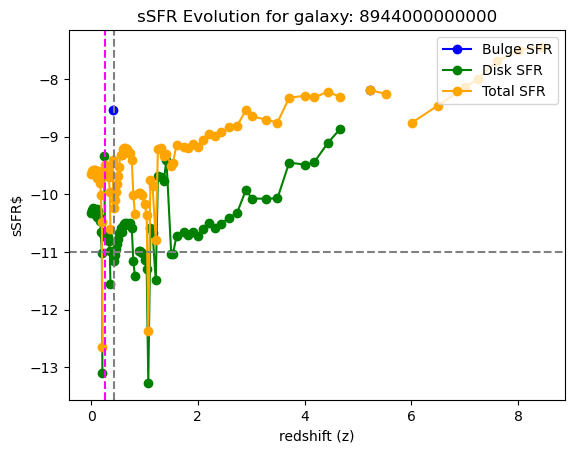

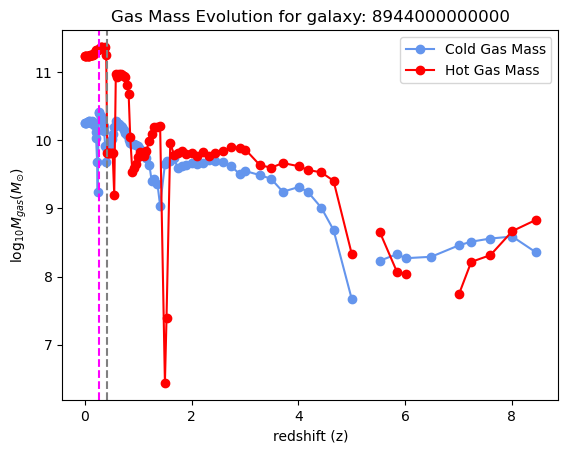

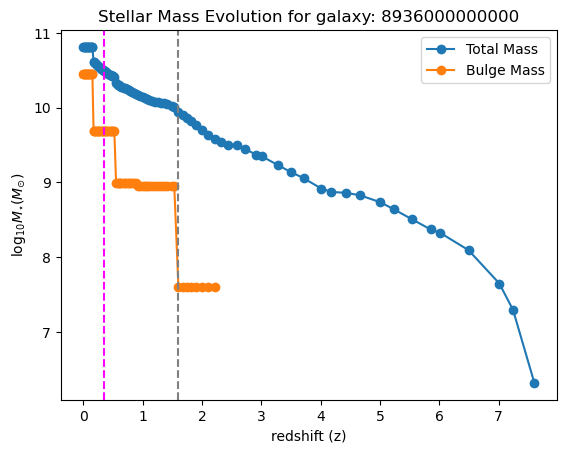

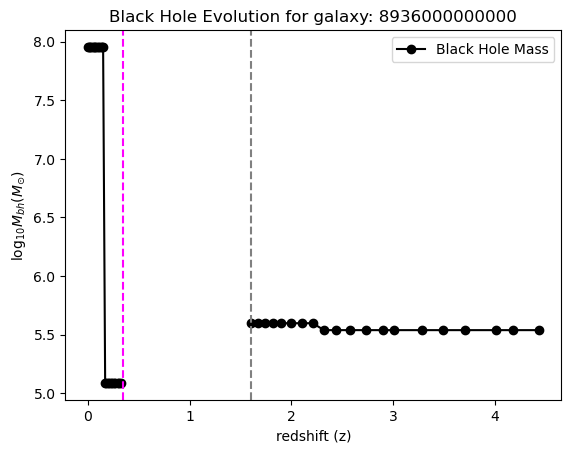

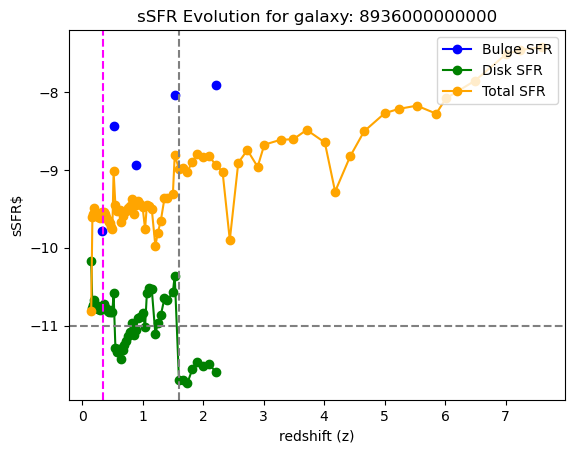

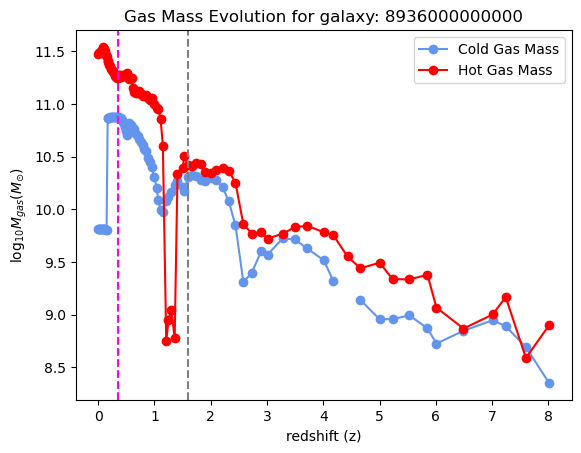

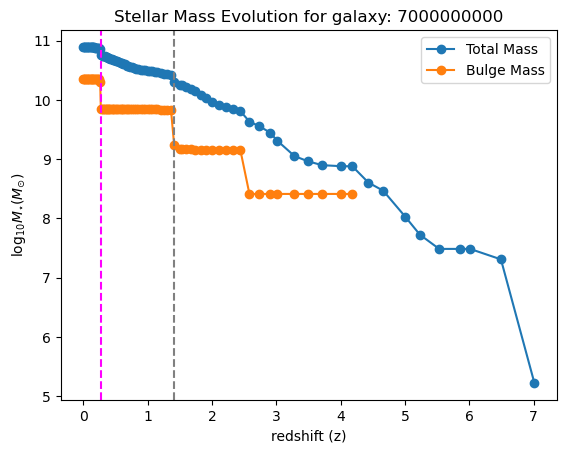

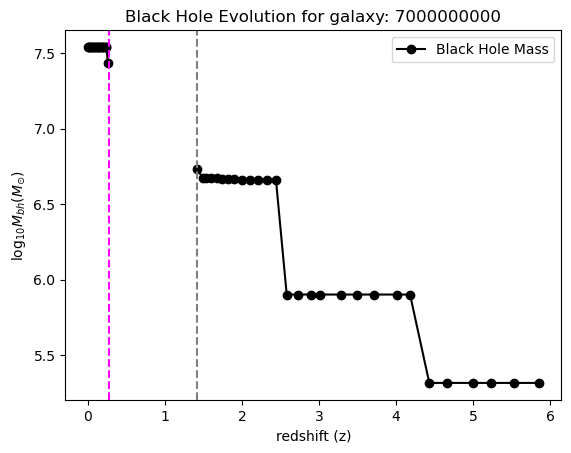

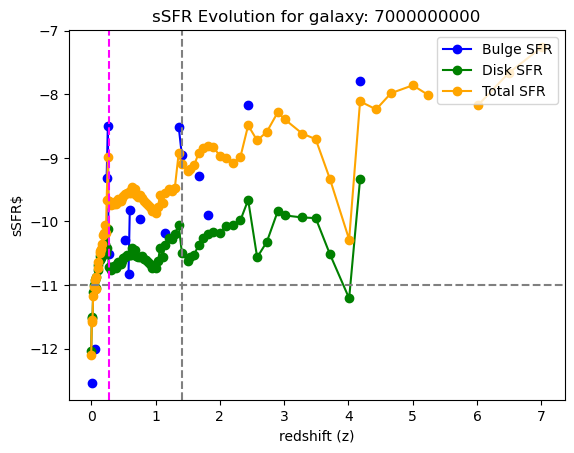

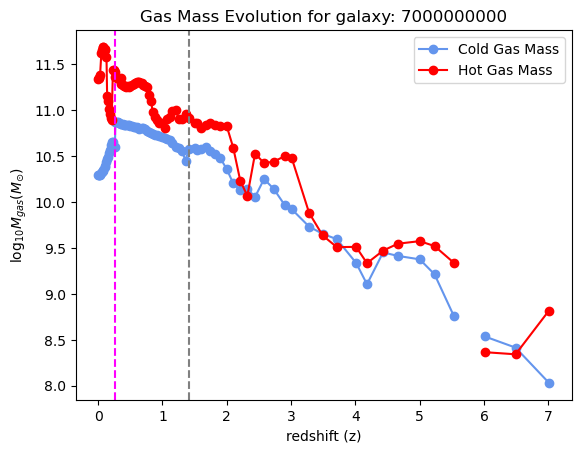

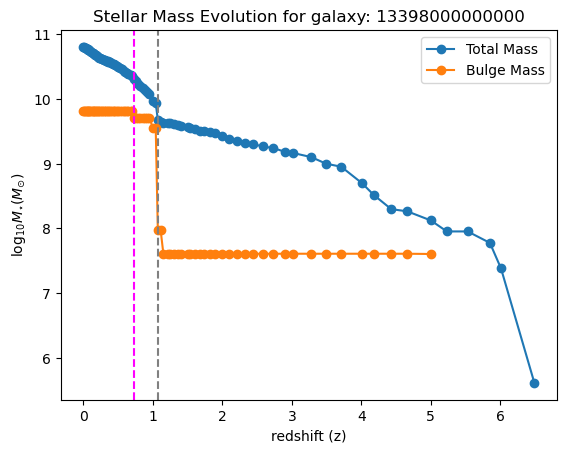

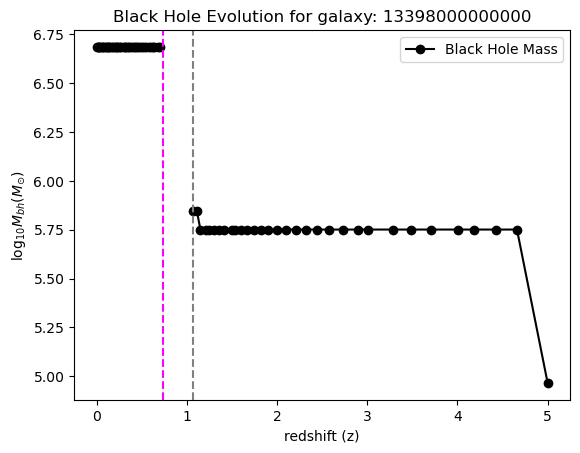

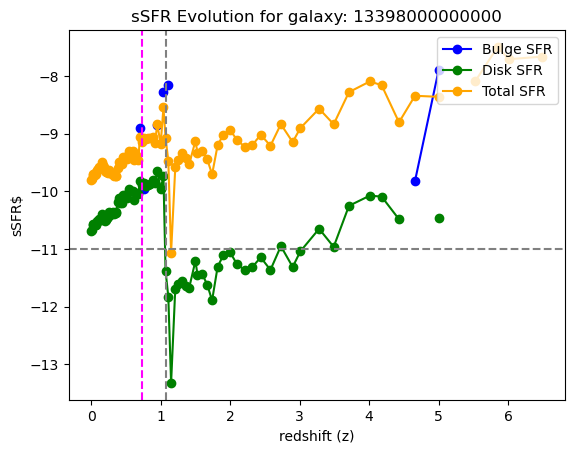

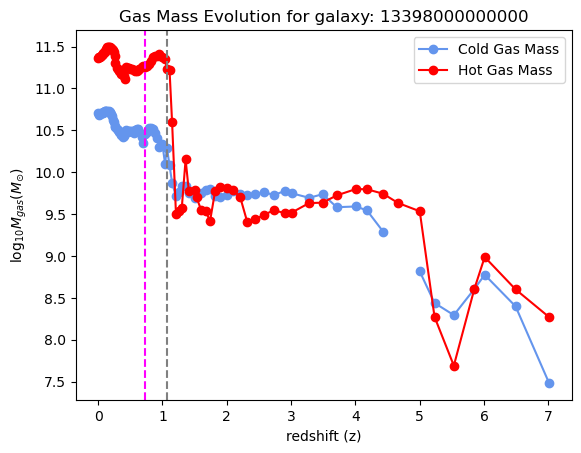

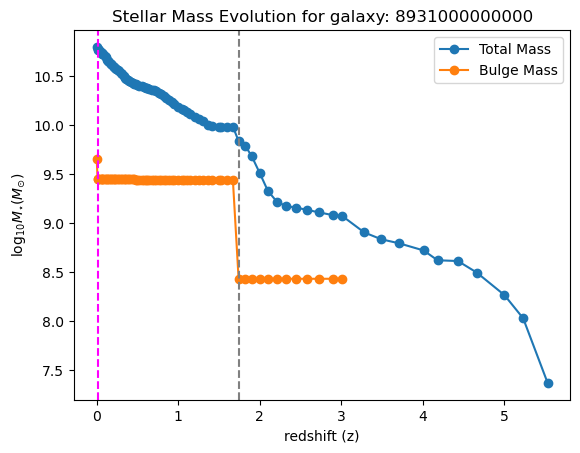

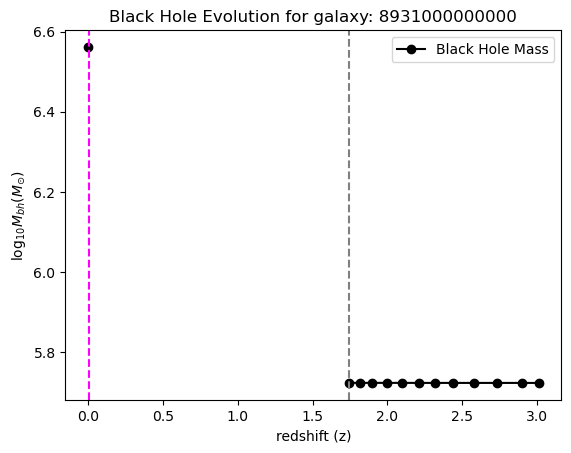

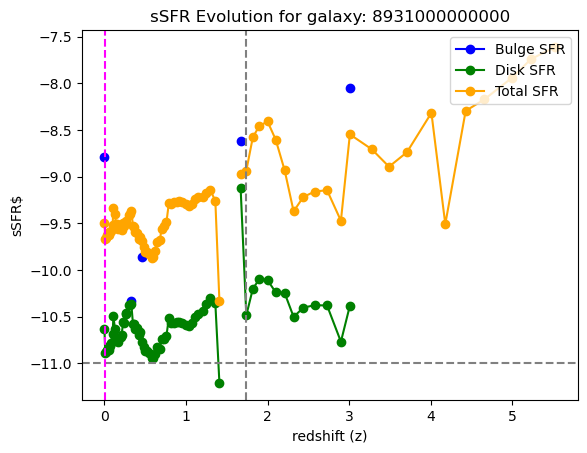

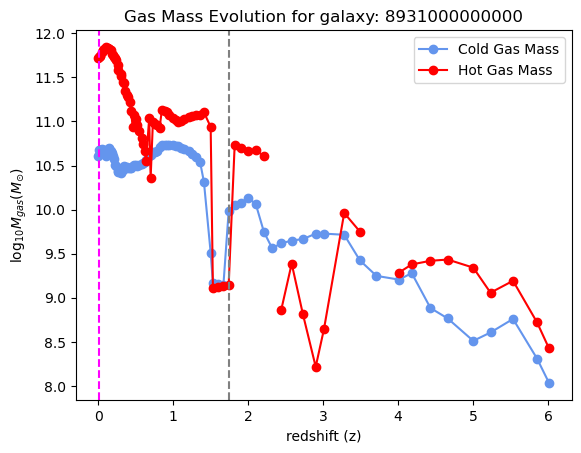

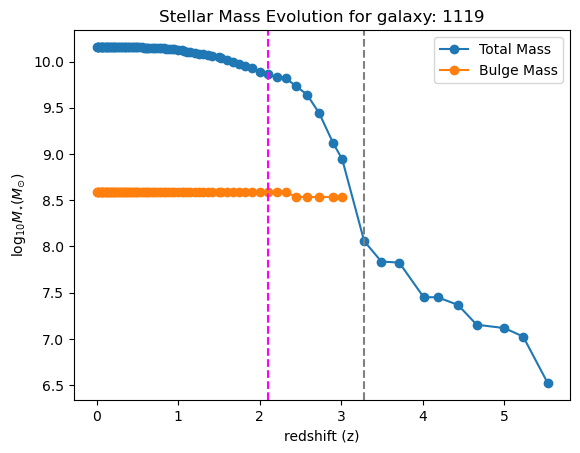

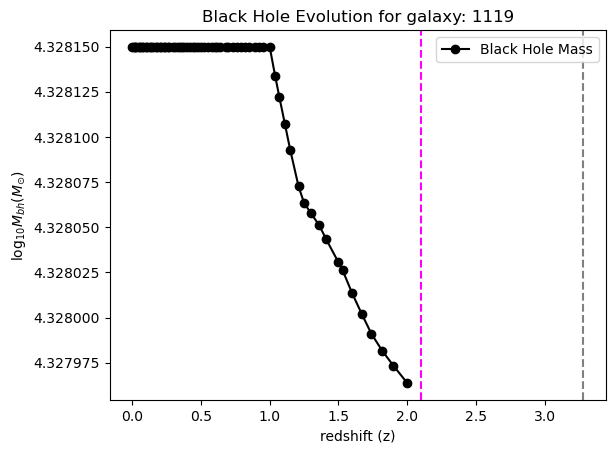

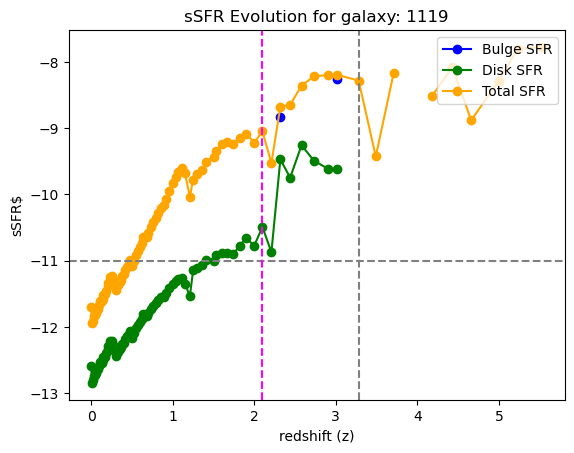

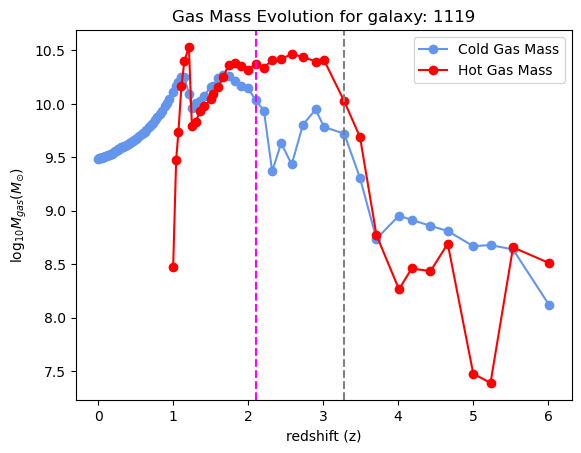

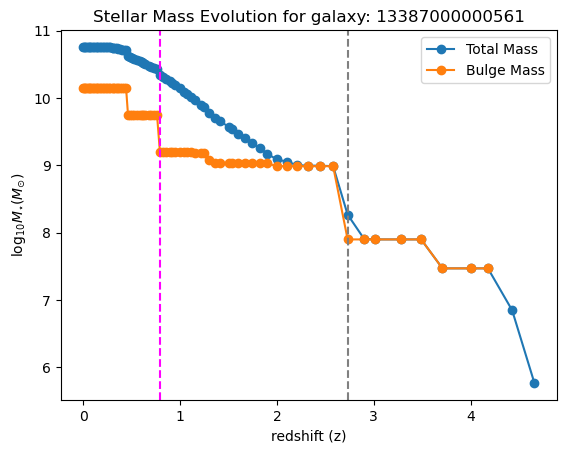

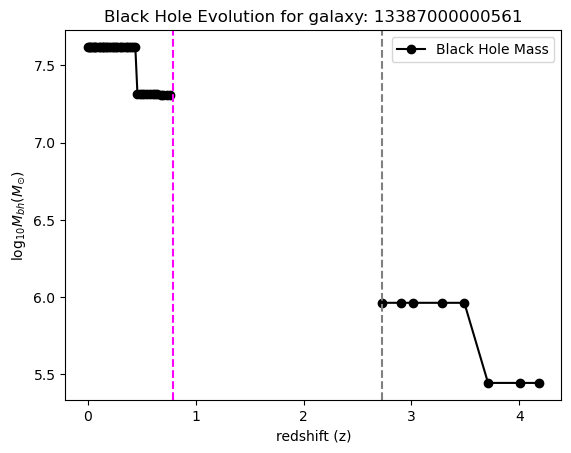

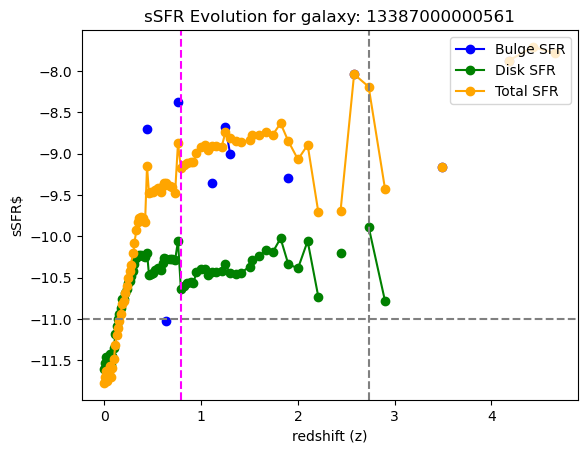

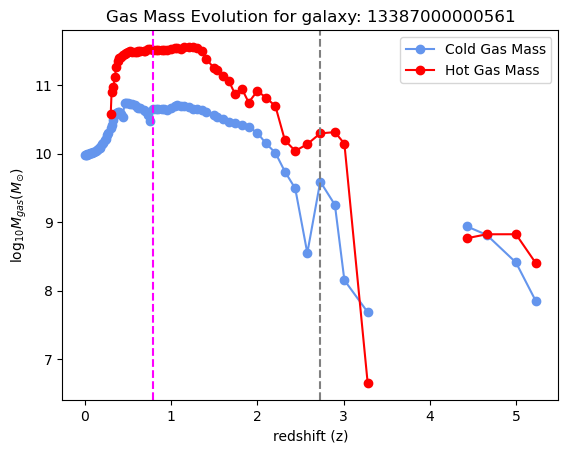

In [12]:
## GALAXIES BULGE MASS THROUGH TIME
bulge_masses = {}



for snap in range(1, 100):
    galaxies = data[snap][0]
    metadata = data[snap][2]

    array_length = len(galaxies)

    for i in range(array_length):
        if galaxies.GalaxyIndex[i] in gal_ids_refilled:
            gal_id = galaxies.GalaxyIndex[i]
            z = metadata['redshift']
            bulge_mass = safe_log10(galaxies.BulgeMass[i] * 1e10 / hubble_h)
            stellar_mass = safe_log10(galaxies.StellarMass[i] * 1e10 / hubble_h)
            disk_mass = stellar_mass - bulge_mass
            cold_gas = safe_log10(galaxies.ColdGas[i] * 1e10 / hubble_h)
            hot_gas = safe_log10(galaxies.HotGas[i] * 1e10 / hubble_h)
            bh_mass = safe_log10(galaxies.BlackHoleMass[i] * 1e10 / hubble_h)
            bulge_sfr = safe_log10(galaxies.SfrBulge[i]) - bulge_mass
            disk_sfr = safe_log10(galaxies.SfrDisk[i]) - (disk_mass + cold_gas)
            total_sfr = safe_log10(galaxies.SfrBulge[i] + galaxies.SfrDisk[i]) - stellar_mass 

            if gal_id not in bulge_masses:
                bulge_masses[gal_id] = {'redshift': [], 
                'bulge_mass': [],  
                'disk_mass': [],
                'stellar_mass': [],
                'cold_gas': [],
                'hot_gas': [],
                'bh_mass': [], 
                'bulge_sfr': [],
                'disk_sfr': [],
                'total_sfr': [],
                'eject_time': [], 
                'refill_time': []}

            bulge_masses[gal_id]['redshift'].append(z)
            bulge_masses[gal_id]['bulge_mass'].append(bulge_mass)
            bulge_masses[gal_id]['stellar_mass'].append(stellar_mass)
            bulge_masses[gal_id]['disk_mass'].append(disk_mass)
            bulge_masses[gal_id]['cold_gas'].append(cold_gas)
            bulge_masses[gal_id]['hot_gas'].append(hot_gas)
            bulge_masses[gal_id]['bh_mass'].append(bh_mass)
            bulge_masses[gal_id]['bulge_sfr'].append(bulge_sfr)
            bulge_masses[gal_id]['disk_sfr'].append(disk_sfr)
            bulge_masses[gal_id]['total_sfr'].append(total_sfr)

            if galaxies.BHEjectedTime[i] > 0:
                bulge_masses[gal_id]['eject_time'].append(previous_redshift)

            if galaxies.BHRefilledTime[i] > 0:
                bulge_masses[gal_id]['refill_time'].append(previous_redshift)

    previous_redshift = metadata['redshift']


for gal_id in bulge_masses:
    ## FOR BULGE, DISK, AND TOTAL STELLAR MASS
    plt.plot(bulge_masses[gal_id]['redshift'], bulge_masses[gal_id]['stellar_mass'], marker = 'o', label='Total Mass')
    # plt.plot(bulge_masses[gal_id]['redshift'], bulge_masses[gal_id]['disk_mass'], marker = 'o', label='Disk Mass')
    plt.plot(bulge_masses[gal_id]['redshift'], bulge_masses[gal_id]['bulge_mass'], marker = 'o', label='Bulge Mass')

    for ejection in bulge_masses[gal_id]['eject_time']:
        plt.axvline(ejection, linestyle = 'dashed', color='grey')
    for refill in bulge_masses[gal_id]['refill_time']:
        plt.axvline(refill, linestyle = 'dashed', color='magenta') 
    
    plt.xlabel('redshift (z)')
    plt.ylabel(r'log$_{10}M_{\star} (M_{\odot})$')
    plt.title(f'Stellar Mass Evolution for galaxy: {gal_id}')
    plt.legend(loc='upper right')
    plt.show()

    ## FOR BLACK HOLE MASS
    plt.plot(bulge_masses[gal_id]['redshift'], bulge_masses[gal_id]['bh_mass'], marker = 'o', color='black', label='Black Hole Mass')

    for ejection in bulge_masses[gal_id]['eject_time']:
        plt.axvline(ejection, linestyle = 'dashed', color='grey')
    for refill in bulge_masses[gal_id]['refill_time']:
        plt.axvline(refill, linestyle = 'dashed', color='magenta') 
    
    plt.xlabel('redshift (z)')
    plt.ylabel(r'log$_{10}M_{bh} (M_{\odot})$')
    plt.title(f'Black Hole Evolution for galaxy: {gal_id}')
    plt.legend(loc='upper right')
    plt.show()

    ## FOR SFRs
    plt.plot(bulge_masses[gal_id]['redshift'], bulge_masses[gal_id]['bulge_sfr'], marker = 'o', color='blue', label='Bulge SFR')
    plt.plot(bulge_masses[gal_id]['redshift'], bulge_masses[gal_id]['disk_sfr'], marker = 'o', color='green', label='Disk SFR')
    plt.plot(bulge_masses[gal_id]['redshift'], bulge_masses[gal_id]['total_sfr'], marker = 'o', color='orange', label='Total SFR')
    plt.axhline(-11, linestyle='dashed', color='grey')

    for ejection in bulge_masses[gal_id]['eject_time']:
        plt.axvline(ejection, linestyle = 'dashed', color='grey')
    for refill in bulge_masses[gal_id]['refill_time']:
        plt.axvline(refill, linestyle = 'dashed', color='magenta') 
    
    plt.xlabel('redshift (z)')
    plt.ylabel(r'sSFR$')
    plt.title(f'sSFR Evolution for galaxy: {gal_id}')
    plt.legend(loc='upper right')
    plt.show()

    ## FOR COLD AND HOT GAS MASS
    plt.plot(bulge_masses[gal_id]['redshift'], bulge_masses[gal_id]['cold_gas'], marker = 'o', color='cornflowerblue', label='Cold Gas Mass')
    plt.plot(bulge_masses[gal_id]['redshift'], bulge_masses[gal_id]['hot_gas'], marker = 'o', color = 'red', label='Hot Gas Mass')

    for ejection in bulge_masses[gal_id]['eject_time']:
        plt.axvline(ejection, linestyle = 'dashed', color='grey')
    for refill in bulge_masses[gal_id]['refill_time']:
        plt.axvline(refill, linestyle = 'dashed', color='magenta') 
    
    plt.xlabel('redshift (z)')
    plt.ylabel(r'log$_{10}M_{gas} (M_{\odot})$')
    plt.title(f'Gas Mass Evolution for galaxy: {gal_id}')
    plt.legend(loc='upper right')
    plt.show()






14948
The number of galaxies in this mass bin 6 - 7: 1545
The number of galaxies w mergers in this mass bin 6 - 7: 0
The number of galaxies w merged BHs in this mass bin 6 - 7: 0
The number of galaxies w ejected BHs in this mass bin 6 - 7: 0
The number of galaxies in this mass bin 7 - 8: 5648
The number of galaxies w mergers in this mass bin 7 - 8: 1
The number of galaxies w merged BHs in this mass bin 7 - 8: 1
The number of galaxies w ejected BHs in this mass bin 7 - 8: 1
The number of galaxies in this mass bin 8 - 9: 5049
The number of galaxies w mergers in this mass bin 8 - 9: 6
The number of galaxies w merged BHs in this mass bin 8 - 9: 6
The number of galaxies w ejected BHs in this mass bin 8 - 9: 3
The number of galaxies in this mass bin 9 - 10: 1522
The number of galaxies w mergers in this mass bin 9 - 10: 29
The number of galaxies w merged BHs in this mass bin 9 - 10: 29
The number of galaxies w ejected BHs in this mass bin 9 - 10: 16
The number of galaxies in this mass bin 10 

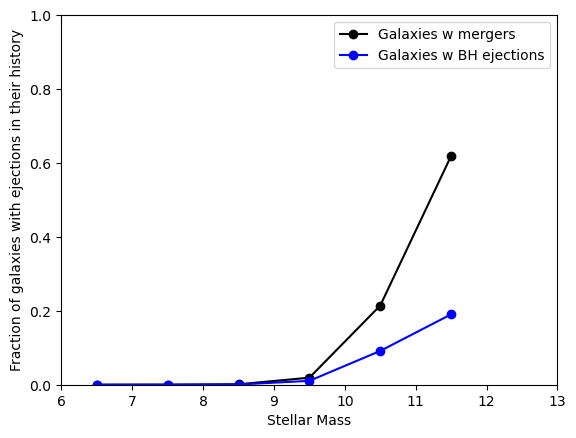

In [17]:
## EJECTION FRACTION PLOT WITH ERROR BARS
def safe_div(numerator, denominator):
        if denominator > 0:
            return numerator / denominator
        else:
            return 0.0

w = galaxies_z0.StellarMass > 0
merge_mask = w & (galaxies_z0.mergeCount > 0)
bh_merge_mask = w & (galaxies_z0.BHmergeCount > 0)
eject_mask = w & (galaxies_z0.BHejectCount > 0)
stellar_mass = np.log10(galaxies_z0.StellarMass[w] * 1e10 / hubble_h)
stellar_mass_merge = np.log10(galaxies_z0.StellarMass[bh_merge_mask] * 1e10 / hubble_h)
stellar_mass_eject = np.log10(galaxies_z0.StellarMass[eject_mask] * 1e10 / hubble_h)
print(len(stellar_mass))


min_range = 6
max_range = 13
interval = 1
nbins = int((max_range - min_range) / interval)
mass_bins = np.arange(min_range, max_range, interval)



mass = []  # Bin centers
gal_merge_fraction = []
bh_merge_fraction = []
bh_eject_fraction = []
errors = []
for i in range(nbins - 1):
        # All galaxies_z0 in this mass bin
        this_bin_mask = (stellar_mass >= mass_bins[i]) & (stellar_mass < mass_bins[i + 1])
        this_bin_count = np.sum(this_bin_mask)
        print(f'The number of galaxies in this mass bin {mass_bins[i]} - {mass_bins[i+1]}: {this_bin_count}')

        # galaxies_z0 that have had mergers in this mass bin
        gal_merge_mask = (stellar_mass_merge >= mass_bins[i]) & (stellar_mass_merge < mass_bins[i + 1])
        gal_merge_count = np.sum(gal_merge_mask)
        print(f'The number of galaxies w mergers in this mass bin {mass_bins[i]} - {mass_bins[i+1]}: {gal_merge_count}')

        # galaxies_z0 that have had merged black holes in this mass bin
        bh_merge_mask = (stellar_mass_merge >= mass_bins[i]) & (stellar_mass_merge < mass_bins[i + 1])
        bh_merge_count = np.sum(bh_merge_mask)
        print(f'The number of galaxies w merged BHs in this mass bin {mass_bins[i]} - {mass_bins[i+1]}: {bh_merge_count}')

        # galaxies_z0 that have had ejected black holes in this mass bin
        bh_eject_mask = (stellar_mass_eject >= mass_bins[i]) & (stellar_mass_eject < mass_bins[i + 1])
        bh_eject_count = np.sum(bh_eject_mask)
        print(f'The number of galaxies w ejected BHs in this mass bin {mass_bins[i]} - {mass_bins[i+1]}: {bh_eject_count}')

        #Calculate occupation fraction
        gal_merge_fraction.append(safe_div(gal_merge_count, this_bin_count))
        bh_merge_fraction.append(safe_div(bh_merge_count, this_bin_count))
        bh_eject_fraction.append(safe_div(bh_eject_count, this_bin_count))

        # Store the mass bin center
        mass.append((mass_bins[i] + mass_bins[i + 1]) / 2.0)

plt.plot(mass, gal_merge_fraction, color='black', marker='o', label='Galaxies w mergers')
# plt.plot(mass, bh_merge_fraction, color='red', marker='o', label='Galaxies w BH-BH mergers')
plt.plot(mass, bh_eject_fraction, color='blue', marker='o', label='Galaxies w BH ejections')
plt.xlabel('Stellar Mass')
plt.ylabel('Fraction of galaxies with ejections in their history')
plt.xlim(min_range, max_range)
plt.ylim(0, 1)
plt.legend()